# Семинар 3-4. Линейная и логистическая регрессии

**Дисциплина «ИИ и машинное обучение»** · НИУ ВШЭ, Высшая школа бизнеса

Магистратура «Бизнес-аналитика и цифровые решения в финансах»

Два кейса на настоящих данных: в первом ответ — число (регрессия),
во втором «да или нет» (классификация). Модели те же, что на лекции.

Оба кейса решаем следующим образом:

> применили модель → получили плохой результат → пошли разбираться
> в данных → нашли проблему → починили → применили снова → увидели,
> насколько стало лучше

Смысл семинара — научиться готовить данные так, чтобы к ним можно было
применять линейные модели.

| Часть | Кейс |
|---|---|
| 1 | Оценка залога: сколько стоит дом |
| 2 | Кредитный скоринг: выдавать ли кредит |

**Как работать.** Тетрадка читается и запускается сверху вниз: каждый
шаг опирается на результат предыдущего, поэтому ячейки надо выполнять
по порядку и смотреть, что изменилось после очередной починки данных.

### Импорт библиотек и вспомогательные функции:

In [ ]:
## ── библиотеки ─────────────────────────────────────────────────────
import numpy as np                      # массивы и математика
import pandas as pd                     # таблицы: чтение csv, группировки, статистика
import matplotlib.pyplot as plt         # графики

# деление данных на части и нарезка кусков для кросс-валидации
from sklearn.model_selection import train_test_split, KFold
# модели: линейная регрессия, она же со штрафом за большие веса, логистическая
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
# Pipeline склеивает подготовку данных и модель в один объект для упрощения работы
from sklearn.pipeline import Pipeline
# ColumnTransformer — своя обработка для каждой группы столбцов
from sklearn.compose import ColumnTransformer
# clone делает необученную копию модели — понадобится в кросс-валидации
from sklearn.base import clone
# подготовка признаков: категории в нули и единицы, масштабирование и произведения признаков
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer       # заполнение пропусков
# метрики: средняя ошибка в единицах ответа, доля объяснённого разброса,
# доля верных ответов, таблица ошибок, качество упорядочивания
from sklearn.metrics import (mean_absolute_error, r2_score, accuracy_score,
                             confusion_matrix, roc_auc_score)

## ── настройки печати и графиков ────────────────────────────────────
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.width", 120)
plt.rcParams.update({
    "figure.figsize": (7.2, 3.8), "figure.dpi": 110, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, INK, RED, GREY, GREEN = "#0057b8", "#0d2340", "#c0392b", "#8a9bb0", "#1b7f5a"

SEED = 42


## ── вспомогательные функции ────────────────────────────────────────
def remember(store, name, value, metric, unit="", lower_better=True):
    "Записывает результат шага в лестницу качества и печатает его с размерностью."
    store.append((name, value, metric, unit))
    print("Шаг «%s»: %s на валидации = %s" % (name, metric, show(value, unit)))
    if len(store) > 1:
        was = store[-2]
        delta = value - was[1]
        good = delta < 0 if lower_better else delta > 0
        print("   на шаге «%s» было %s — стало %s на %s"
              % (was[0], show(was[1], unit), "лучше" if good else "хуже",
                 show(abs(delta), unit)))
    return value


def show(value, unit=""):
    "Число с размерностью: деньги с копейками, метрики с четырьмя знаками."
    text = "%.2f" % value if abs(value) >= 10 else "%.4f" % value
    return (text + " " + unit).strip()


def show_ladder(store, title, lower_better=True, start=0.0):
    "Рисует лестницу качества по всем пройденным шагам."
    names = [row[0] for row in store]
    vals = [row[1] for row in store]
    unit = store[-1][3]
    good = min(vals) if lower_better else max(vals)
    bad = max(vals) if lower_better else min(vals)
    cols = [BLUE if v == good else RED if v == bad else GREY for v in vals]
    top = max(vals) + (max(vals) - start) * 0.3
    fig, ax = plt.subplots(figsize=(7.6, 0.52 * len(store) + 1.2))
    ax.barh(range(len(store)), [v - start for v in vals], left=start, color=cols)
    ax.set_yticks(range(len(store)))
    ax.set_yticklabels(names)
    ax.invert_yaxis()
    ax.set_xlim(start, top)
    ax.grid(axis="y", alpha=0)
    ax.set_title(title)
    ax.set_xlabel(("%s, %s" % (store[-1][2], unit)) if unit else store[-1][2])
    for i, v in enumerate(vals):
        ax.text(v + (top - start) * 0.012, i, show(v, unit), va="center", fontsize=10)
    plt.show()


print("Готово. scikit-learn", __import__("sklearn").__version__)

---
# Часть 1. Оценка залога: сколько стоит дом

**Ситуация.** Банк выдаёт кредиты под залог недвижимости, и перед выдачей
объект надо **оценить**. Ручная оценка стоит денег и занимает дни; нужна
модель, которая по характеристикам дома сразу называет цену.

**Метрика — MAE**, средняя ошибка **в долларах**: её можно обосновать банку,
и все поймут. Также смотрим R².

**Данные.** 1460 реальных сделок с жильём в городе Эймс, штат Айова,
2006–2010 годы. Читаем готовый файл из репозитория курса — одной строкой,
без установки и регистрации.

Первоисточник — набор `house_prices` на openml.org,
[openml.org/d/42165](https://www.openml.org/d/42165) (изначально эти данные
собраны для соревнования Kaggle «House Prices»). Там они лежат в том виде,
в каком их собирали риелторы в Айове: 81 столбец, английские названия,
площади в **квадратных футах**, тип сделки кодом вроде `Partial`. Поэтому
к семинару с ними заранее сделали три вещи:

* **отобрали столбцы** — из 81 взяли 22 (для упрощения анализа на семинаре):
  цену и 21 признак;
* **перевели единицы** — футы в метры, чтобы числа были привычными;
* **перевели названия и коды** — на русский, чтобы таблица читалась.

**Больше ничего не делали.** Пропуски, выбросы и странные значения остались
на месте: именно с ними мы и будем разбираться на протяжении всего семинара.

In [ ]:
## ── данные ─────────────────────────────────────────────────────────
# read_csv читает таблицу прямо по ссылке: файл лежит в репозитории курса,
# скачивать и распаковывать ничего не нужно
HOUSES = ("https://raw.githubusercontent.com/Rimest/ml_ai_course_gsb_hse"
          "/main/data/ames_houses.csv")
houses = pd.read_csv(HOUSES)

y = houses["цена"]        # это ответ, его модель и будет предсказывать

print("Сделок: %d, столбцов про каждую: %d" % houses.shape)

houses.head()             # head показывает первые пять строк

| Столбец | Что это |
|---|---|
| `цена` | за сколько продали, $ — **это ответ** |
| `жилая_площадь` | м² |
| `площадь_1_этажа`, `площадь_2_этажа` | м² |
| `площадь_подвала`, `площадь_участка`, `площадь_гаража` | м² |
| `длина_фасада` | ширина участка вдоль улицы, м |
| `качество_отделки`, `состояние` | оценки от 1 до 10 |
| `год_постройки`, `год_ремонта`, `год_продажи` | годы |
| `мест_в_гараже`, `санузлов`, `комнат`, `каминов` | штуки |
| `район`, `тип_застройки`, `качество_кухни`, `кондиционер` | категории |
| `тип_сделки` | обычная, между родственниками, дом ещё строился… |

## Шаг 0. Отдаём модели таблицу как есть

Самый честный первый шаг: взять данные, какими они пришли, и попросить
модель обучиться. Посмотрим, что будет.

In [4]:
try:
    LinearRegression().fit(houses.drop(columns=["цена"]), y)
except Exception as e:
    print("Не обучилась:", type(e).__name__)
    print(str(e)[:200])

Не обучилась: ValueError
could not convert string to float: 'CollgCr'


In [5]:
houses.dtypes

цена                  int64
жилая_площадь       float64
площадь_1_этажа     float64
площадь_2_этажа     float64
площадь_подвала     float64
площадь_участка     float64
длина_фасада        float64
качество_отделки      int64
состояние             int64
год_постройки         int64
год_ремонта           int64
год_продажи           int64
мест_в_гараже         int64
площадь_гаража      float64
санузлов              int64
комнат                int64
каминов               int64
район                object
тип_застройки        object
качество_кухни       object
кондиционер          object
тип_сделки           object
dtype: object

In [6]:
houses[["район", "тип_застройки", "качество_кухни", "кондиционер", "тип_сделки"]]

,район,тип_застройки,качество_кухни,кондиционер,тип_сделки
0,CollgCr,жилая малоэтажная,хорошее,есть,обычная
1,Veenker,жилая малоэтажная,среднее,есть,обычная
2,CollgCr,жилая малоэтажная,хорошее,есть,обычная
3,Crawfor,жилая малоэтажная,хорошее,есть,нетипичная
4,NoRidge,жилая малоэтажная,хорошее,есть,обычная
...,...,...,...,...,...
1455,Gilbert,жилая малоэтажная,среднее,есть,обычная
1456,NWAmes,жилая малоэтажная,среднее,есть,обычная
1457,Crawfor,жилая малоэтажная,хорошее,есть,обычная
1458,NAmes,жилая малоэтажная,хорошее,есть,обычная


In [7]:
houses.isna().sum()

цена                  0
жилая_площадь         0
площадь_1_этажа       0
площадь_2_этажа       0
площадь_подвала       0
площадь_участка       0
длина_фасада        259
качество_отделки      0
состояние             0
год_постройки         0
год_ремонта           0
год_продажи           0
мест_в_гараже         0
площадь_гаража        0
санузлов              0
комнат                0
каминов               0
район                 0
тип_застройки         0
качество_кухни        0
кондиционер           0
тип_сделки            0
dtype: int64

Модель не приняла данные вообще. Причин две, и обе видны в таблице:

1. **Текст.** Район называется `NAmes`, а не числом. Умножить вес
   на слово нельзя.
2. **Пропуски.** В `длина_фасада` 259 пустых клеток, и `NaN` ломает
   арифметику.

Значит, первый шаг — «заставить модель хотя бы
запуститься». Это и есть первая подготовка данных.

## train, validation, test

Перед первым обучением поделим датасет на **три** части:

* **обучение** (60 %) — на нём модель подбирает веса;
* **валидация** (20 %) — на ней мы сравниваем аналитические решения
  между собой;
* **тест** (20 %) — замеряем финальное качество.

Зачем третья часть? Мы будем много раз выбирать: какие столбцы взять,
какое преобразование сделать, какую силу штрафа поставить. Если делать
этот выбор по тесту, мы подгоним под него решения и получим завышенную
оценку качества. Поэтому **тест открываем один раз, в самом конце**.

На шаге 6 к валидации добавится ещё и кросс-валидация, и окажется,
что одному разбиению верить нельзя.

In [8]:
## ── делим дома на три части ────────────────────────────────────────
# train_test_split перемешивает объекты и делит их на две части;
# делим дома на обучение 60 %, валидацию 20 % и тест 20 %
fit, test = train_test_split(houses.index, test_size=0.2, random_state=SEED)
train, valid = train_test_split(fit, test_size=0.25, random_state=SEED)

print("Сколько домов в какой части:")
for name, part in (("обучение — модель подбирает веса", train),
                   ("валидация — оцениваем промежуточный результат", valid),
                   ("тест — оцениваем итоговое качество", test)):
    print("   %-50s домов %d" % (name, len(part)))

## ── где пропуски ───────────────────────────────────────────────────
# isna() ставит True на месте пустой клетки, sum() считает их по столбцам
gaps = houses.isna().sum()
gaps = gaps[gaps > 0].sort_values(ascending=False)
print("\nВ каком столбце пусто:")
for name, n in gaps.items():
    print("   %-14s пустых клеток %d — это %.0f %% домов"
          % (name, n, 100 * n / len(houses)))

## ── лестница качества ──────────────────────────────────────────────
LADDER = []          # сюда складываем результат каждого шага

Сколько домов в какой части:
   обучение — модель подбирает веса                   домов 876
   валидация — оцениваем промежуточный результат      домов 292
   тест — оцениваем итоговое качество                 домов 292

В каком столбце пусто:
   длина_фасада   пустых клеток 259 — это 18 % домов


## Посмотрим, какие столбцы вообще связаны с ценой

Прежде чем что-то обучать, полезно предварительно посмотреть на данные:
какие столбцы связаны с ценой, а какие повторяют друг друга. Для числовых
столбцов на этот вопрос отвечает **корреляция** — число от −1 до 1: единица
значит «растут вместе», ноль — «никак не связаны», минус единица — «один
растёт, другой падает».

Слева на картинке — связь каждого столбца с ценой. Справа — связь
столбцов друг с другом; подписаны пары, где корреляция выше 0,80.

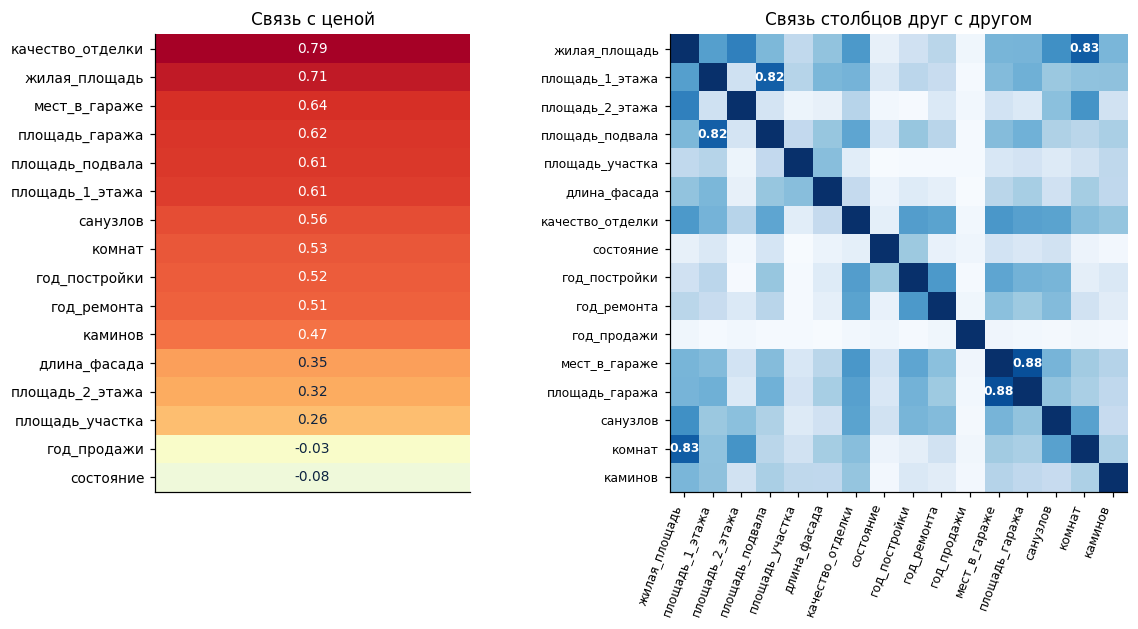

Корреляция пар столбцов:
   жилая_площадь      и комнат             0.83
   мест_в_гараже      и площадь_гаража     0.88
   жилая_площадь      и площадь_1_этажа    0.57
   жилая_площадь      и площадь_2_этажа    0.69
   сумма площадей этажей равна жилой площади у 98 % домов


In [9]:
## ── считаем корреляции ─────────────────────────────────────────────
# select_dtypes("number") оставляет только числовые столбцы
NUMERIC = list(houses.select_dtypes("number").columns.drop("цена"))

# corrwith: корреляция каждого столбца с ценой
with_price = houses[NUMERIC].corrwith(y).sort_values(ascending=False)
# corr: та же корреляция, но каждого столбца с каждым; abs — знак нам не важен
pairs = houses[NUMERIC].corr().abs()

## ── графики ────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(12.6, 5.4),
                       gridspec_kw={"width_ratios": [1, 2.1]})

ax[0].imshow(with_price.values.reshape(-1, 1), cmap="RdYlBu_r",
             vmin=-0.8, vmax=0.8, aspect="auto")
for i, v in enumerate(with_price.values):
    ax[0].text(0, i, "%.2f" % v, ha="center", va="center", fontsize=9,
               color="white" if abs(v) > 0.45 else INK)
ax[0].set_xticks([])
ax[0].set_yticks(range(len(with_price)))
ax[0].set_yticklabels(with_price.index, fontsize=9)
ax[0].set_title("Связь с ценой", fontsize=11)
ax[0].grid(False)

ax[1].imshow(pairs.values, cmap="Blues", vmin=0, vmax=1)
for i in range(len(NUMERIC)):
    for j in range(len(NUMERIC)):
        if i != j and pairs.iloc[i, j] >= 0.80:
            ax[1].text(j, i, "%.2f" % pairs.iloc[i, j], ha="center", va="center",
                       fontsize=8, color="white", fontweight="bold")
ax[1].set_xticks(range(len(NUMERIC)))
ax[1].set_xticklabels(NUMERIC, rotation=70, ha="right", fontsize=8)
ax[1].set_yticks(range(len(NUMERIC)))
ax[1].set_yticklabels(NUMERIC, fontsize=8)
ax[1].set_title("Связь столбцов друг с другом", fontsize=11)
ax[1].grid(False)
plt.show()

## ── проверяем руками ───────────────────────────────────────────────
# а теперь проверим руками то, чего карта корреляций не показывает
floors = houses["площадь_1_этажа"] + houses["площадь_2_этажа"]
same = (houses["жилая_площадь"] - floors).abs() < 0.5
print("Корреляция пар столбцов:")
for a, b in (("жилая_площадь", "комнат"), ("мест_в_гараже", "площадь_гаража"),
             ("жилая_площадь", "площадь_1_этажа"), ("жилая_площадь", "площадь_2_этажа")):
    print("   %-18s и %-18s %.2f" % (a, b, pairs.loc[a, b]))
print("   сумма площадей этажей равна жилой площади у %.0f %% домов"
      % (100 * same.mean()))

Что видно:

* сильнее всего цена связана с **качеством отделки** (0,79) и **жилой
  площадью** (0,71) — их точно берём;
* **состояние** и **год продажи** с ценой почти не связаны (−0,08
  и −0,03). Само по себе это уже полезно знать: год продажи можно не брать;
* есть пары, которые измеряют одно и то же дважды: `мест_в_гараже`
  и `площадь_гаража` (0,88), `жилая_площадь` и `комнат` (0,83),
  `площадь_подвала` и `площадь_1_этажа` (0,82 — у большинства домов
  подвал под всем первым этажом). Это **мультиколлинеарность**
  с лекции;
* а последняя строка таблицы — самое интересное. Площадь первого этажа
  плюс площадь второго **в точности равны** жилой площади у 98 % домов,
  хотя по отдельности каждый этаж связан с ней средне (0,57 и 0,69).
  Карта корреляций такую связь не показывает: она смотрит на пары,
  а здесь связаны *три* столбца сразу.

Поэтому в список числовых столбцов возьмём жилую площадь, а площади
этажей — нет. Почему это важно, проверим сразу после первого обучения.

In [10]:
NUM = ["жилая_площадь", "площадь_подвала", "площадь_участка", "длина_фасада",
       "качество_отделки", "состояние", "год_постройки", "год_ремонта",
       "мест_в_гараже", "площадь_гаража", "санузлов", "комнат", "каминов"]
CAT = ["район", "тип_застройки", "качество_кухни", "кондиционер"]

print("Что делаем со столбцами:")
for name, count in (("числовые — берём в модель", len(NUM)),
                    ("текстовые — пока откладываем", len(CAT) + 1),
                    ("площади этажей — не берём, повторяют жилую", 2)):
    print("   %-44s %2d" % (name, count))

Что делаем со столбцами:
   числовые — берём в модель                    13
   текстовые — пока откладываем                  5
   площади этажей — не берём, повторяют жилую    2


## Шаг 1. Минимум, чтобы модель заработала

Делаем ровно две вещи: выбрасываем все текстовые столбцы и заполняем
пропуски медианой. Никакой хитрости — просто чтобы `fit` не упал.

Сначала посмотрим на то, что собираемся предсказывать.

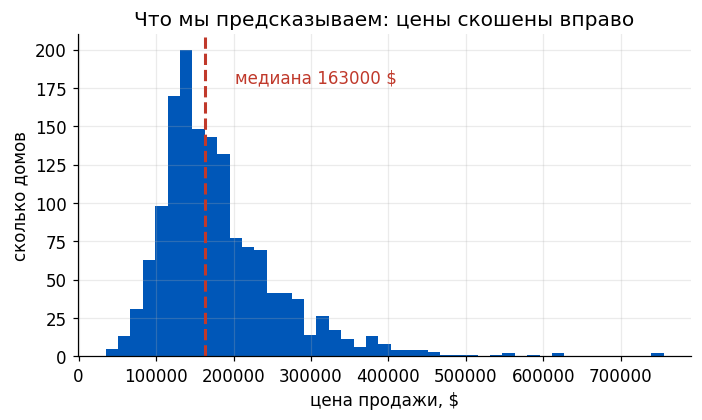

Что мы предсказываем:
   самый дешёвый дом:                    34900.00 $
   половина домов дешевле — это медиана: 163000.00 $
   самый дорогой дом:                    755000.00 $
   10 % от медианной цены:               16300.00 $


In [11]:
median_price = y.median()      # median — серединное значение: половина домов дешевле

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots()
# hist показывает, сколько объектов попало в каждый интервал цен
ax.hist(y, bins=45, color=BLUE)
ax.axvline(median_price, color=RED, lw=2, ls="--")
ax.annotate("медиана %.0f $" % median_price, (median_price, ax.get_ylim()[1] * 0.85),
            xytext=(20, 0), textcoords="offset points", color=RED, fontsize=11)
ax.set_xlabel("цена продажи, $")
ax.set_ylabel("сколько домов")
ax.set_title("Что мы предсказываем: цены скошены вправо")
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("Что мы предсказываем:")
print("   самый дешёвый дом:                    %s" % show(y.min(), "$"))
print("   половина домов дешевле — это медиана: %s" % show(median_price, "$"))
print("   самый дорогой дом:                    %s" % show(y.max(), "$"))
print("   10 %% от медианной цены:               %s" % show(0.1 * median_price, "$"))

Половина домов дешевле 163 тысяч, а самый дорогой — 755 тысяч. Значит,
понятная планка такая: ошибка в 16 тысяч долларов — это 10 % от цены
типичного дома.

**Числовые столбцы живут в разных единицах.** У площади участка
типичное значение около тысячи квадратных метров, у жилой площади — сто
сорок, год постройки — это число около двух тысяч, а состояние дома —
балл от 1 до 10. Модель умножает каждый столбец на свой вес и всё
складывает, поэтому вес при площади участка получится маленьким,
а при состоянии — большим: не потому, что участок неважен, а потому,
что сами числа разного размера. Сравнивать такие веса между собой
нельзя, а на шаге 6 мы будем ещё и штрафовать их за величину — и штраф
достался бы не тем столбцам.

>`StandardScaler` приводит столбцы к общему виду: из каждого он вычитает
>среднее этого столбца и делит на его разброс. После этого у всех
>столбцов среднее 0 и разброс 1, а значение «1,5» читается одинаково
>в любом столбце — «на полтора разброса выше среднего». Посмотрите
>на таблицу до и после.

In [12]:
## ── четыре столбца до масштабирования ──────────────────────────────
peek = ["площадь_участка", "жилая_площадь", "год_постройки", "состояние"]
rows = train[:5]                       # пять домов из обучающей части

print("Было — каждый столбец в своих единицах:")
print(houses.loc[rows, peek].to_string())

## ── те же столбцы после StandardScaler ─────────────────────────────
# fit_transform делает сразу две вещи: запоминает среднее и разброс
# каждого столбца (fit) и пересчитывает по ним таблицу (transform)
scaled = pd.DataFrame(StandardScaler().fit_transform(houses.loc[train, peek]),
                      index=train, columns=peek)

print("\nСтало — всё в одной шкале, «на сколько разбросов от среднего»:")
print(scaled.loc[rows].round(2).to_string())

## ── что изменилось в каждом столбце ────────────────────────────────
print("\n%-18s %12s %12s %14s %13s"
      % ("столбец", "было среднее", "был разброс",
         "стало среднее", "стало разброс"))
for col in peek:
    # после масштабирования среднее равно нулю с точностью до округления
    print("%-18s %12.0f %12.0f %14.2f %13.2f"
          % (col, houses.loc[train, col].mean(), houses.loc[train, col].std(),
             abs(scaled[col].mean()), scaled[col].std()))

Было — каждый столбец в своих единицах:
      площадь_участка  жилая_площадь  год_постройки  состояние
683            1045.0          155.0           2002          5
1077           1474.4          101.8           1969          5
463            1113.7          154.2           1934          7
657             668.9          139.5           1931          6
835             891.9           99.1           1950          7

Стало — всё в одной шкале, «на сколько разбросов от среднего»:
      площадь_участка  жилая_площадь  год_постройки  состояние
683              0.03           0.26           1.03      -0.53
1077             0.42          -0.82          -0.04      -0.53
463              0.09           0.24          -1.18       1.24
657             -0.31          -0.06          -1.27       0.36
835             -0.11          -0.88          -0.66       1.24

столбец            было среднее  был разброс  стало среднее стало разброс
площадь_участка            1011         1109           0.00      

На прогноз обычной линейной регрессии масштаб при этом не влияет: модель
подберёт другие веса и выдаст те же самые цены. Масштабирование нужно
для другого — чтобы веса можно было сравнивать между собой, чтобы штраф
за большие веса на шаге 6 давил на все столбцы одинаково и чтобы
градиентный спуск сходился за разумное число шагов.

**Из чего собрана модель.** В ячейке ниже три инструмента sklearn,
и каждый делает ровно одну вещь:

* `SimpleImputer(strategy="median")` — заполняет пропуски: ставит на место
  каждой пустой клетки медиану её столбца;
* `StandardScaler()` — то самое масштабирование: вычитает из столбца его
  среднее и делит на его разброс;
* `LinearRegression()` — сама модель: подбирает по одному весу на столбец
  и складывает вклады.

Склеивает их `Pipeline([...])` — список пар «название этапа, инструмент».
Данные идут по нему сверху вниз: сначала пропуски, потом масштаб, потом
модель. Выгода в том, что у всей цепочки всего два метода, и они
одинаковы у любой модели в sklearn:

* `конвейер.fit(X, y)` — обучение: `X` это таблица признаков, `y` — ответы.
  Настраиваются все три этапа сразу: медианы считаются по обучающим домам,
  среднее с разбросом — по ним же, веса — по ним же;
* `конвейер.predict(X)` — прогноз: на входе такая же таблица признаков,
  на выходе массив предсказанных цен, по одной на каждую строку. К новым
  домам применяются те медианы и тот масштаб, что **запомнились при обучении**.

Собираем конвейер из этих трёх этапов, обучаем его на числовых столбцах
обучающей части и считаем MAE и R² **на валидации**.

In [13]:
## ── обучение ───────────────────────────────────────────────────────
m1 = Pipeline([
    ("пропуски", SimpleImputer(strategy="median")),
    ("масштаб", StandardScaler()),
    ("модель", LinearRegression()),
])
m1.fit(houses.loc[train, NUM], y.loc[train])

## ── качество на валидации ──────────────────────────────────────────
pred1 = m1.predict(houses.loc[valid, NUM])
# mean_absolute_error — средний промах по модулю, в долларах
mae1 = mean_absolute_error(y.loc[valid], pred1)
# r2_score — какую долю разброса цен модель объяснила: 1 идеально, 0 бесполезно
r2_1 = r2_score(y.loc[valid], pred1)

print("Шаг 1 на валидации:")
print("   MAE — средний промах в долларах:               %s" % show(mae1, "$"))
print("   R² — какую долю разброса цен объяснила модель: %s" % show(r2_1))
print("   промах в процентах от медианной цены:          %.1f %%"
      % (100 * mae1 / median_price))
remember(LADDER, "1. числа как есть", mae1, "MAE", "$")

Шаг 1 на валидации:
   MAE — средний промах в долларах:               23059.13 $
   R² — какую долю разброса цен объяснила модель: 0.8047
   промах в процентах от медианной цены:          14.1 %
Шаг «1. числа как есть»: MAE на валидации = 23059.13 $


23059.12693545666

Модель заработала. Много ли это — ошибаться на 23 тысячи? Посмотрим
на ту же картинку с ценами и нарисуем ошибку модели прямо на ней.

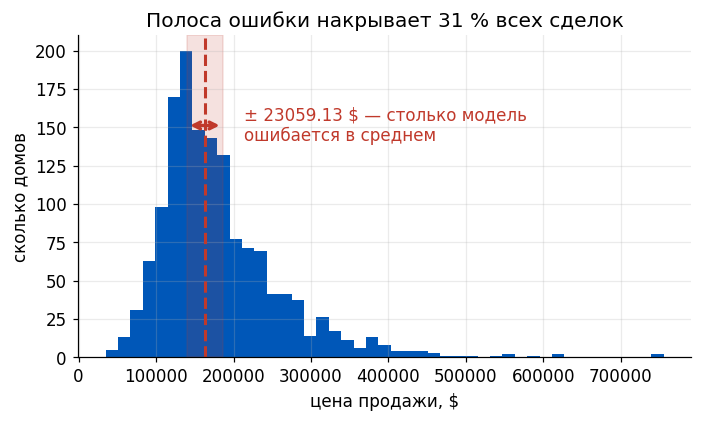

In [14]:
# сколько домов попадает в полосу «медиана ± средняя ошибка»
band = (y > median_price - mae1) & (y < median_price + mae1)

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots()
ax.hist(y, bins=45, color=BLUE)
top = ax.get_ylim()[1]
ax.axvspan(median_price - mae1, median_price + mae1, color=RED, alpha=0.15)
ax.axvline(median_price, color=RED, lw=2, ls="--")
ax.annotate("", (median_price - mae1, top * 0.72), (median_price + mae1, top * 0.72),
            arrowprops=dict(arrowstyle="<->", color=RED, lw=2.2))
ax.annotate("± %s — столько модель\nошибается в среднем" % show(mae1, "$"),
            (median_price + mae1, top * 0.72), xytext=(14, 0),
            textcoords="offset points", ha="left", va="center", color=RED, fontsize=11)
ax.set_xlabel("цена продажи, $")
ax.set_ylabel("сколько домов")
ax.set_title("Полоса ошибки накрывает %.0f %% всех сделок" % (100 * band.mean()))
plt.show()

Полоса ошибки накрывает почти треть всех сделок: по такому прогнозу дом
за 140 тысяч не отличить от дома за 186 тысяч. Для оценки залога это
неприемлемо. Смотрим, где именно модель врёт.

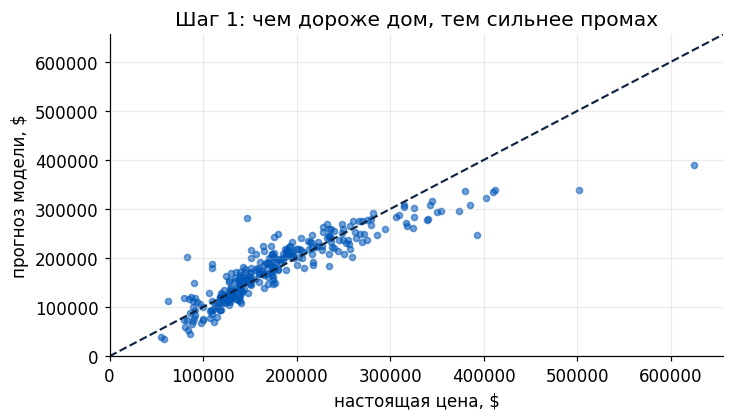

In [15]:
fig, ax = plt.subplots()
ax.scatter(y.loc[valid], pred1, s=16, color=BLUE, alpha=0.55)
lim = [0, y.loc[valid].max() * 1.05]
ax.plot(lim, lim, color=INK, lw=1.4, ls="--")
ax.set_xlabel("настоящая цена, $")
ax.set_ylabel("прогноз модели, $")
ax.set_title("Шаг 1: чем дороже дом, тем сильнее промах")
ax.set_xlim(lim)
ax.set_ylim(lim)
plt.show()

### Обещанная проверка: почему мы не взяли площади этажей

Мы выяснили, что площадь первого этажа плюс площадь второго дают жилую
площадь. Что будет, если дать модели все три столбца сразу? Обучим её
пять раз на случайных 80 % обучающих домов — как будто нам каждый раз
достались немного другие данные — и посмотрим на **вес жилой площади**.

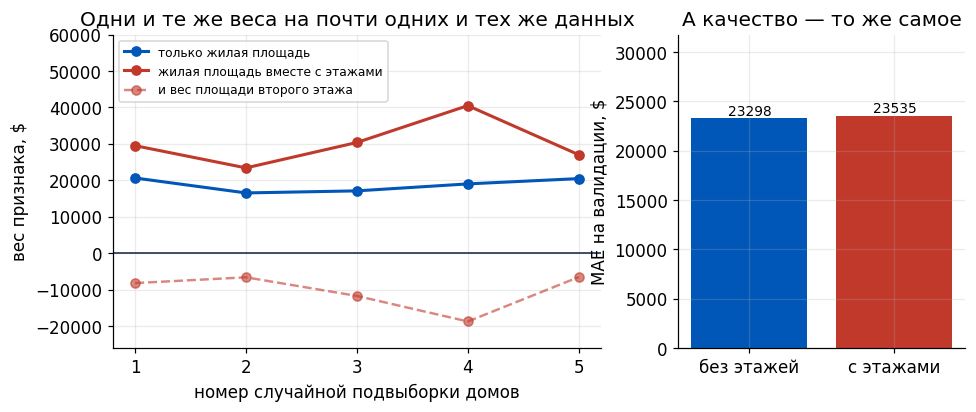

Вес жилой площади по пяти подвыборкам:
                                        от           до  MAE в среднем
   только жилая площадь         16543.48 $   20636.31 $     23297.66 $
   жилая площадь и оба этажа    23411.80 $   40499.46 $     23535.21 $

Если дать все три столбца, веса гуляют так:
   жилая площадь          от   23411.80 $ до   40499.46 $
   площадь первого этажа  от  -10566.24 $ до    2370.42 $
   площадь второго этажа  от  -18728.68 $ до   -6547.69 $


In [16]:
DUP = ["площадь_1_этажа", "площадь_2_этажа"]


## ── функция: веса на случайной части обучения ──────────────────────
def weights_on_part(cols, seed):
    "Обучает конвейер шага 1 на случайных 80 % обучающих домов: веса и MAE."
    part = pd.Index(np.random.RandomState(seed).choice(train, int(0.8 * len(train)),
                                                       replace=False))
    model = Pipeline([("пропуски", SimpleImputer(strategy="median")),
                      ("масштаб", StandardScaler()),
                      ("модель", LinearRegression())])
    model.fit(houses.loc[part, cols], y.loc[part])
    # coef_ — подобранные веса, их порядок совпадает с порядком столбцов
    out = dict(zip(cols, model.named_steps["модель"].coef_))
    out["MAE"] = mean_absolute_error(y.loc[valid], model.predict(houses.loc[valid, cols]))
    return out


## ── пять подвыборок ────────────────────────────────────────────────
without = pd.DataFrame([weights_on_part(NUM, s) for s in range(5)])
with_dup = pd.DataFrame([weights_on_part(NUM + DUP, s) for s in range(5)])

## ── графики ────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.7),
                       gridspec_kw={"width_ratios": [1.7, 1]})
ax[0].plot(range(1, 6), without["жилая_площадь"], "o-", color=BLUE, lw=2,
           label="только жилая площадь")
ax[0].plot(range(1, 6), with_dup["жилая_площадь"], "o-", color=RED, lw=2,
           label="жилая площадь вместе с этажами")
ax[0].plot(range(1, 6), with_dup["площадь_2_этажа"], "o--", color=RED, lw=1.6,
           alpha=0.6, label="и вес площади второго этажа")
ax[0].axhline(0, color=INK, lw=1)
ax[0].set_xticks(range(1, 6))
ax[0].set_xlabel("номер случайной подвыборки домов")
ax[0].set_ylabel("вес признака, $")
ax[0].set_ylim(-26000, 60000)
ax[0].set_title("Одни и те же веса на почти одних и тех же данных")
ax[0].legend(fontsize=8, loc="upper left")

ax[1].bar(["без этажей", "с этажами"],
          [without["MAE"].mean(), with_dup["MAE"].mean()], color=[BLUE, RED])
ax[1].set_ylim(0, with_dup["MAE"].mean() * 1.35)
ax[1].set_ylabel("MAE на валидации, $")
ax[1].set_title("А качество — то же самое")
for i, v in enumerate([without["MAE"].mean(), with_dup["MAE"].mean()]):
    ax[1].text(i, v, "%.0f" % v, ha="center", va="bottom", fontsize=9)
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("Вес жилой площади по пяти подвыборкам:")
print("   %-26s %12s %12s %14s" % ("", "от", "до", "MAE в среднем"))
for name, frame in (("только жилая площадь", without),
                    ("жилая площадь и оба этажа", with_dup)):
    print("   %-26s %12s %12s %14s"
          % (name, show(frame["жилая_площадь"].min(), "$"),
             show(frame["жилая_площадь"].max(), "$"), show(frame["MAE"].mean(), "$")))

print("\nЕсли дать все три столбца, веса гуляют так:")
for name, col in (("жилая площадь", "жилая_площадь"),
                  ("площадь первого этажа", "площадь_1_этажа"),
                  ("площадь второго этажа", "площадь_2_этажа")):
    print("   %-22s от %12s до %12s"
          % (name, show(with_dup[col].min(), "$"), show(with_dup[col].max(), "$")))

Качество от этого не изменилось — разница в пару сотен долларов при
общей ошибке в 23 тысячи. А вот веса поехали. Там, где столбцы дублируют
друг друга, модель может раздать вес между ними почти как угодно:
прогноз выйдет тот же, а слагаемые каждый раз разные.

Смотрите на вторую таблицу. Вес жилой площади гуляет от 23 до 40 тысяч
в зависимости от того, какие 80 % домов нам достались, — а без дублей он
держался в узком коридоре 16–21 тысяча. Вес площади второго этажа вообще
получился **отрицательным**: по такой модели выходит, что второй этаж
уменьшает цену дома.

Для прогноза это не страшно: сумма вкладов остаётся правильной. Страшно для
**объяснения** — именно веса показывают менеджеру, именно ими обосновывают
решение, а здесь они означают не то, что мы думаем. Поэтому дублирующие
столбцы или не берут вовсе, или гасят штрафом, до которого мы дойдём на шаге
6.

## Шаг 2. Выбросы: две сделки, которые «ломают линейность»

Первое, что делают с числовыми данными, — смотрят на них глазами.

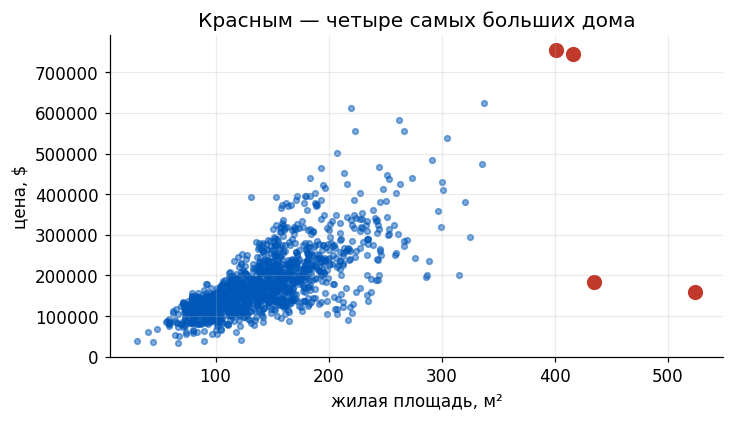

In [17]:
fig, ax = plt.subplots()
ax.scatter(houses["жилая_площадь"], y, s=14, color=BLUE, alpha=0.5)
big = houses[houses["жилая_площадь"] > 370]
ax.scatter(big["жилая_площадь"], big["цена"], s=80, color=RED)
ax.set_xlabel("жилая площадь, м²")
ax.set_ylabel("цена, $")
ax.set_title("Красным — четыре самых больших дома")
plt.show()

Два огромных дома проданы по цене обычных. Посмотрим на эти четыре
строки в таблице — там всё написано.

In [18]:
# sort_values упорядочивает строки таблицы по значению столбца
print(big[["жилая_площадь", "цена", "качество_отделки", "тип_сделки"]]
      .sort_values("жилая_площадь").to_string())

      жилая_площадь    цена  качество_отделки        тип_сделки
691           401.0  755000                10           обычная
1182          415.8  745000                10        нетипичная
523           434.4  184750                10  дом ещё строился
1298          524.2  160000                10  дом ещё строился


Вот и объяснение: у двух самых больших домов тип сделки —
**«дом ещё строился»**. Это продажа недостроя застройщиком, цена там
не рыночная. Два других дома по 400 м² стоят под 750 тысяч, и с ними
всё в порядке — они просто дорогие.

Важный момент: **выброс объяснился другим столбцом**, а не «ошибкой
в данных». Ищем причину, а потом решаем, что делать.

Убираем недострой **только из обучения**. Валидацию и тест не трогаем:
они изображают поток заявок из жизни, а в жизни такие объекты тоже
будут приходить.

Строим обучающую выборку без двух недостроев и обучаем на ней ту же
модель.

Шаг 2:
   домов в обучении было:      876
   из них выбросили недострой: 2
   MAE на валидации:           21581.33 $
   R² на валидации:            0.8307
Шаг «2. без недостроя»: MAE на валидации = 21581.33 $
   на шаге «1. числа как есть» было 23059.13 $ — стало лучше на 1477.80 $


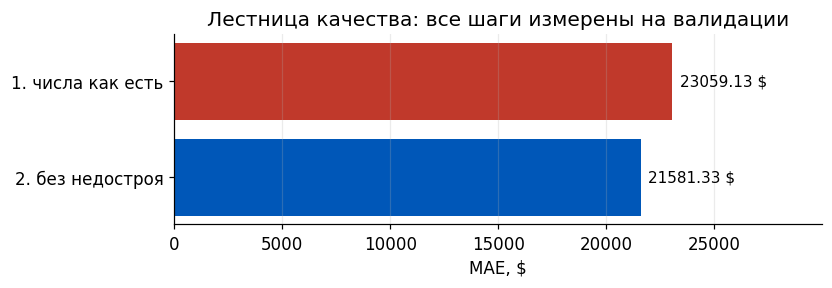

In [19]:
## ── обучающая выборка без недостроя ────────────────────────────────
strange = ((houses.loc[train, "тип_сделки"] == "дом ещё строился")
           & (houses.loc[train, "жилая_площадь"] > 370))
# ~strange читается как «все, кроме недостроя»
clean = train[~strange]

## ── обучение ───────────────────────────────────────────────────────
m2 = Pipeline([
    ("пропуски", SimpleImputer(strategy="median")),
    ("масштаб", StandardScaler()),
    ("модель", LinearRegression()),
])
m2.fit(houses.loc[clean, NUM], y.loc[clean])

## ── качество на валидации ──────────────────────────────────────────
pred2 = m2.predict(houses.loc[valid, NUM])
mae2 = mean_absolute_error(y.loc[valid], pred2)

print("Шаг 2:")
print("   домов в обучении было:      %d" % len(train))
print("   из них выбросили недострой: %d" % strange.sum())
print("   MAE на валидации:           %s" % show(mae2, "$"))
print("   R² на валидации:            %s" % show(r2_score(y.loc[valid], pred2)))
remember(LADDER, "2. без недостроя", mae2, "MAE", "$")
show_ladder(LADDER, "Лестница качества: все шаги измерены на валидации")

Две строки из 876 улучшили прогноз для **всех** остальных домов почти
на полторы тысячи долларов. Это чувствительность квадрата ошибки
к выбросам с лекции: MSE наказывает большой промах в квадрате, и модель
разворачивается к далёкой точке.

## Шаг 3. Остатки: модель врёт систематически

Одно число MAE не говорит, **где** модель ошибается. Для этого смотрят
на остатки — разности «факт минус прогноз».

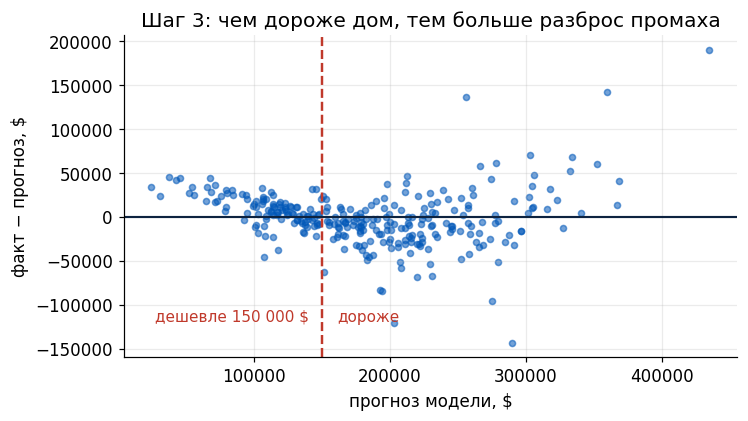

Где модель ошибается (на валидации):
   дешевле 150 000 $ — домов 106, средний промах 15298.29 $
   дороже 250 000 $  — домов 53, средний промах 37176.01 $


In [20]:
## ── считаем остатки ────────────────────────────────────────────────
resid = y.loc[valid] - pred2
cheap, pricey = pred2 < 150000, pred2 > 250000

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots()
ax.scatter(pred2, resid, s=16, color=BLUE, alpha=0.55)
ax.axhline(0, color=INK, lw=1.4)
ax.axvline(150000, color=RED, lw=1.6, ls="--")
ax.annotate("дешевле 150 000 $", (150000, resid.min()), xytext=(-8, 14),
            textcoords="offset points", ha="right", color=RED, fontsize=10)
ax.annotate("дороже", (150000, resid.min()), xytext=(10, 14),
            textcoords="offset points", ha="left", color=RED, fontsize=10)
ax.set_xlabel("прогноз модели, $")
ax.set_ylabel("факт − прогноз, $")
ax.set_title("Шаг 3: чем дороже дом, тем больше разброс промаха")
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("Где модель ошибается (на валидации):")
print("   дешевле 150 000 $ — домов %d, средний промах %s"
      % (cheap.sum(), show(np.abs(resid[cheap]).mean(), "$")))
print("   дороже 250 000 $  — домов %d, средний промах %s"
      % (pricey.sum(), show(np.abs(resid[pricey]).mean(), "$")))

Слева от пунктира промахи в два с половиной раза меньше, чем справа.
Причина в том, что цены скошены вправо, а модель складывает **доллары**
и поэтому одинаково старается и там, и там.

Лечится преобразованием ответа: учим модель предсказывать не цену,
а **логарифм цены**. Посмотрите, что логарифм делает с распределением.

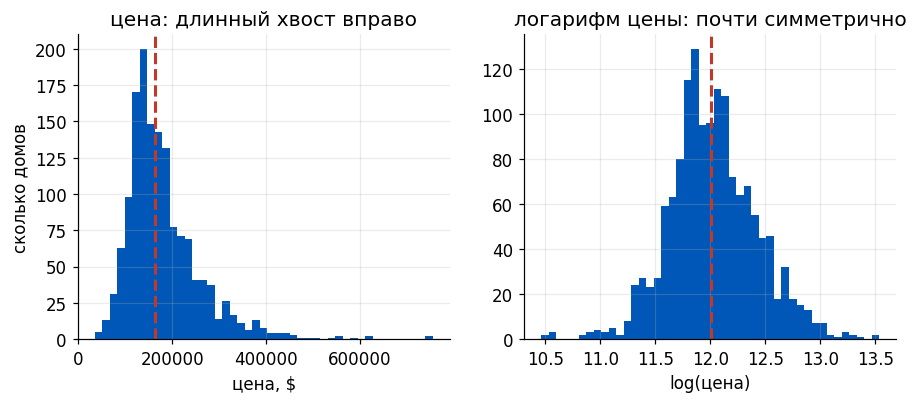

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.6))
ax[0].hist(y, bins=45, color=BLUE)
ax[0].axvline(y.median(), color=RED, lw=2, ls="--")
ax[0].set_title("цена: длинный хвост вправо")
ax[0].set_xlabel("цена, $")
ax[1].hist(np.log(y), bins=45, color=BLUE)
ax[1].axvline(np.log(y).median(), color=RED, lw=2, ls="--")
ax[1].set_title("логарифм цены: почти симметрично")
ax[1].set_xlabel("log(цена)")
ax[0].set_ylabel("сколько домов")
plt.show()

Хвост распрямился. Теперь «ошибиться на 10 %» будет стоить одинаково
для дешёвого и дорогого дома.

Никаких новых инструментов для этого не нужно: конвейер тот же, меняется
только то, что мы даём ему в качестве ответа. Вместо цены даём
`np.log(цена)` — и модель учится предсказывать логарифм. Её прогноз —
тоже логарифм, поэтому в доллары он возвращается обратной операцией,
`np.exp(...)`.

Обучаем тот же конвейер не на цене, а на её логарифме, и сравниваем MAE
с предыдущим шагом.

Шаг 3: MAE на валидации 17021.47 $, R² 0.8889
Шаг «3. + логарифм цены»: MAE на валидации = 17021.47 $
   на шаге «2. без недостроя» было 21581.33 $ — стало лучше на 4559.86 $


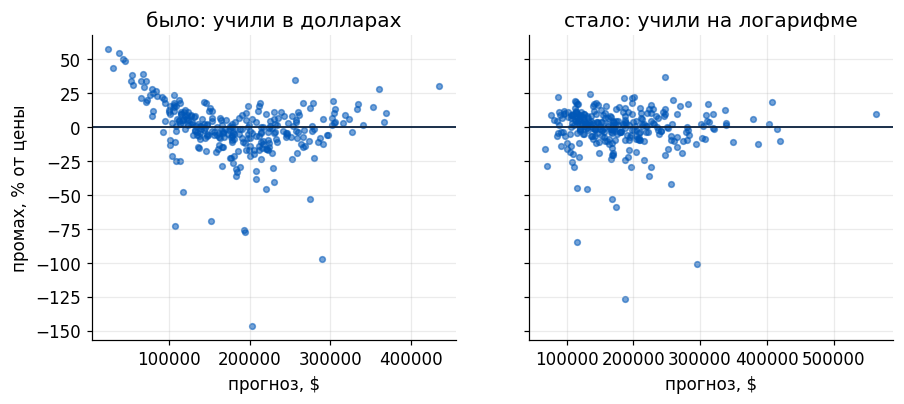

In [22]:
## ── обучение ───────────────────────────────────────────────────────
m3 = Pipeline([
    ("пропуски", SimpleImputer(strategy="median")),
    ("масштаб", StandardScaler()),
    ("модель", LinearRegression()),
])
# вместо цены даём модели её логарифм
log_price = np.log(y.loc[clean])
m3.fit(houses.loc[clean, NUM], log_price)

## ── качество на валидации ──────────────────────────────────────────
# модель предсказывает логарифм — возвращаем доллары обратной операцией
pred3 = np.exp(m3.predict(houses.loc[valid, NUM]))
mae3 = mean_absolute_error(y.loc[valid], pred3)

print("Шаг 3: MAE на валидации %s, R² %s"
      % (show(mae3, "$"), show(r2_score(y.loc[valid], pred3))))
remember(LADDER, "3. + логарифм цены", mae3, "MAE", "$")

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.6), sharey=True)
for a, p, ttl in ((ax[0], pred2, "было: учили в долларах"),
                  (ax[1], pred3, "стало: учили на логарифме")):
    a.scatter(p, (y.loc[valid] - p) / y.loc[valid] * 100, s=14, color=BLUE, alpha=0.55)
    a.axhline(0, color=INK, lw=1.2)
    a.set_title(ttl)
    a.set_xlabel("прогноз, $")
ax[0].set_ylabel("промах, % от цены")
plt.show()

Минус четыре с половиной тысячи за один логарифм. И промах в процентах
перестал зависеть от цены дома: на правой картинке облако точек одинаковой
ширины и для дешёвых домов, и для дорогих, а на левой оно расширялось.

## Шаг 4. А что мы выбросили на первом шаге?

На шаге 1 мы удалили все текстовые столбцы, чтобы модель запустилась.
Пора вернуться и посмотреть, что в них было.

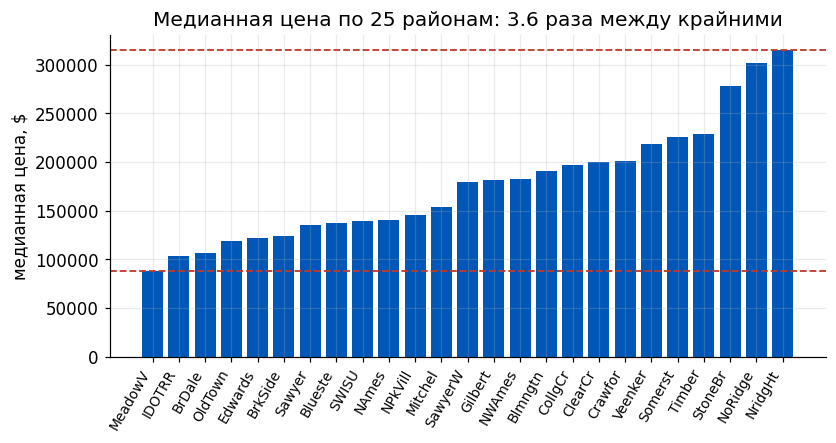

Медианная цена по районам:
   самый дешёвый район MeadowV    88000.00 $
   самый дорогой район NridgHt    315000.00 $
   разница: 3.6 раза


In [23]:
## ── считаем ────────────────────────────────────────────────────────
# groupby делит дома по значению столбца, median считает медиану в каждой группе
med_by_area = y.groupby(houses["район"]).median().sort_values()

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8.4, 3.8))
ax.bar(range(len(med_by_area)), med_by_area.values, color=BLUE)
ax.set_xticks(range(len(med_by_area)))
ax.set_xticklabels(med_by_area.index, rotation=60, ha="right", fontsize=9)
ax.axhline(med_by_area.max(), color=RED, lw=1.2, ls="--")
ax.axhline(med_by_area.min(), color=RED, lw=1.2, ls="--")
ax.set_ylabel("медианная цена, $")
ax.set_title("Медианная цена по 25 районам: %.1f раза между крайними"
             % (med_by_area.max() / med_by_area.min()))
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("Медианная цена по районам:")
print("   самый дешёвый район %-10s %s"
      % (med_by_area.index[0], show(med_by_area.iloc[0], "$")))
print("   самый дорогой район %-10s %s"
      % (med_by_area.index[-1], show(med_by_area.iloc[-1], "$")))
print("   разница: %.1f раза" % (med_by_area.max() / med_by_area.min()))

Медианная цена в самом дорогом районе выше, чем в самом дешёвом, в
3,6 раза! Выбросив текст, мы выбросили важный признак.

**Два новых инструмента.** Числовые и текстовые столбцы надо обработать
по-разному, и в sklearn для этого есть ровно то, что нужно:

* `OneHotEncoder(handle_unknown="ignore")` — переводит категории в числа:
  делает из одного столбца столько столбцов, сколько в нём разных значений,
  и ставит единицу в том, который подходит дому. Из `район` с 25 названиями
  выйдет 25 столбцов, и у дома из `NAmes` единица будет только в столбце
  `NAmes`, в остальных нули. `handle_unknown="ignore"` говорит, что делать,
  если в новых данных попадётся название, которого в обучении не было:
  поставить нули во все столбцы, а не останавливаться с ошибкой;
* `ColumnTransformer([...])` — раздаёт столбцы по обработчикам. Это список
  тройек «название ветки, чем обрабатываем, какие столбцы»: числам —
  пропуски и масштаб, категориям — `OneHotEncoder`. Результаты ветвей
  склеиваются в одну широкую таблицу, она и уходит в модель.

Снаружи всё это снова `Pipeline`: сначала `ColumnTransformer`, потом
`LinearRegression`.

Собираем `ColumnTransformer` с двумя ветками и обучаем модель на всех
столбцах — и числовых, и текстовых.

In [24]:
CAT

['район', 'тип_застройки', 'качество_кухни', 'кондиционер']

In [25]:
encoder = ColumnTransformer(
    transformers=[
        ('категории', OneHotEncoder(sparse_output=False), CAT)
    ],
    remainder='passthrough'
)

# 3. Обучаем и трансформируем данные
encoded_array = encoder.fit_transform(houses)

# 4. Получаем новые имена колонок (включая сгенерированные fixed-колонки)
new_columns = encoder.get_feature_names_out()

# 5. Обновляем DataFrame
df = pd.DataFrame(encoded_array, columns=new_columns)
df

,категории__район_Blmngtn,категории__район_Blueste,категории__район_BrDale,категории__район_BrkSide,категории__район_ClearCr,категории__район_CollgCr,категории__район_Crawfor,категории__район_Edwards,категории__район_Gilbert,категории__район_IDOTRR,...,remainder__состояние,remainder__год_постройки,remainder__год_ремонта,remainder__год_продажи,remainder__мест_в_гараже,remainder__площадь_гаража,remainder__санузлов,remainder__комнат,remainder__каминов,remainder__тип_сделки
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,5,2003,2003,2008,2,50.9,2,8,0,обычная
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8,1976,1976,2007,2,42.7,2,6,1,обычная
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,5,2001,2002,2008,2,56.5,2,6,1,обычная
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,5,1915,1970,2006,3,59.6,1,7,1,нетипичная
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5,2000,2000,2008,3,77.7,2,9,1,обычная
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,5,1999,2000,2007,2,42.7,2,7,1,обычная
1456,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6,1978,1988,2010,2,46.5,2,7,2,обычная
1457,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,9,1941,2006,2010,1,23.4,2,9,2,обычная
1458,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6,1950,1996,2010,1,22.3,1,5,0,обычная


Шаг 4:
   MAE на валидации:             16155.11 $
   R² на валидации:              0.8970
   столбцов было:                17
   столбцов стало после one-hot: 48
Шаг «4. + категории»: MAE на валидации = 16155.11 $
   на шаге «3. + логарифм цены» было 17021.47 $ — стало лучше на 866.36 $


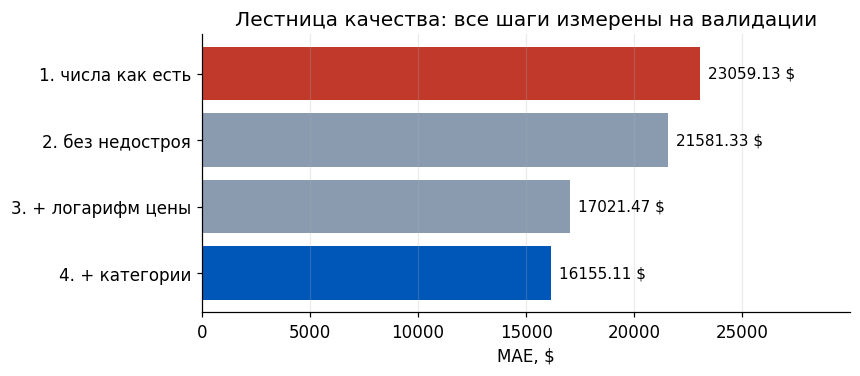

In [26]:
## ── подготовка столбцов ────────────────────────────────────────────
# ветка для чисел: пропуски, потом масштаб
numbers = Pipeline([("пропуски", SimpleImputer(strategy="median")),
                    ("масштаб", StandardScaler())])
# ветка для текста
categories = OneHotEncoder(handle_unknown="ignore")

# каждой группе столбцов — своя ветка
prep4 = ColumnTransformer([("числа", numbers, NUM),
                           ("категории", categories, CAT)])

## ── обучение ───────────────────────────────────────────────────────
m4 = Pipeline([("подготовка", prep4), ("модель", LinearRegression())])
m4.fit(houses.loc[clean, NUM + CAT], np.log(y.loc[clean]))

## ── качество на валидации ──────────────────────────────────────────
pred4 = np.exp(m4.predict(houses.loc[valid, NUM + CAT]))
mae4 = mean_absolute_error(y.loc[valid], pred4)

# named_steps достаёт из конвейера этап по названию
ready4 = m4.named_steps["подготовка"]
print("Шаг 4:")
print("   MAE на валидации:             %s" % show(mae4, "$"))
print("   R² на валидации:              %s" % show(r2_score(y.loc[valid], pred4)))
print("   столбцов было:                %d" % (len(NUM) + len(CAT)))
print("   столбцов стало после one-hot: %d"
      % ready4.transform(houses.loc[clean, NUM + CAT]).shape[1])
remember(LADDER, "4. + категории", mae4, "MAE", "$")
show_ladder(LADDER, "Лестница качества: все шаги измерены на валидации")

## Шаг 5. Граница применимости самой модели

Данные мы починили. Теперь упираемся в ограничение **модели**: она умеет
только складывать вклады признаков. Прибавка за метр у неё одна и та же
и для дома с отделкой на 4 балла, и для дома на 10 баллов. Посмотрим,
так ли это в данных.

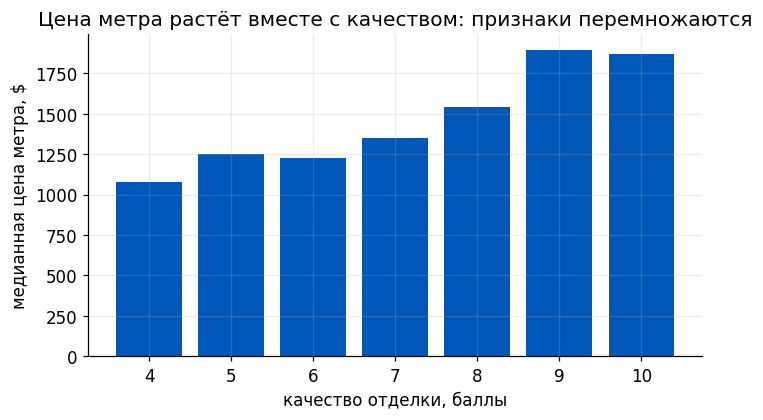

Медианная цена квадратного метра:
   отделка 4 балла:  1080.39 $
   отделка 10 баллов: 1868.70 $
   разница: 1.7 раза


In [27]:
## ── считаем ────────────────────────────────────────────────────────
per_m2 = (y / houses["жилая_площадь"]).groupby(houses["качество_отделки"]).median()
per_m2 = per_m2[per_m2.index >= 4]

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots()
ax.bar(per_m2.index.astype(str), per_m2.values, color=BLUE)
ax.set_xlabel("качество отделки, баллы")
ax.set_ylabel("медианная цена метра, $")
ax.set_title("Цена метра растёт вместе с качеством: признаки перемножаются")
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("Медианная цена квадратного метра:")
print("   отделка %d балла:  %s" % (per_m2.index[0], show(per_m2.iloc[0], "$")))
print("   отделка %d баллов: %s" % (per_m2.index[-1], show(per_m2.iloc[-1], "$")))
print("   разница: %.1f раза" % (per_m2.iloc[-1] / per_m2.iloc[0]))

Цена квадратного метра растёт вместе с качеством отделки в 1,7 раза —
то есть признаки **перемножаются**, а не складываются. Складывать модель
умеет, перемножать — нет.

Лечится не заменой модели, а новыми столбцами: модель **линейна по весам**,
а не по признакам. Считать произведения руками по одному долго, поэтому
в числовую ветку добавим ещё один инструмент:

* `PolynomialFeatures(degree=2, include_bias=False)` — добавляет
  к столбцам их квадраты и все попарные произведения. `degree=2` — до
  второй степени; `include_bias=False` — не добавлять столбец из одних
  единиц, свободный член модель подбирает сама. Из 13 числовых столбцов
  выйдет 104.

В ветке чисел он встаёт между пропусками и масштабом: произведения
считаются от исходных величин, а к одному масштабу приводятся уже все
104 столбца.

**Посмотрите на двух столбцах, что это значит.** Из столбцов $a$ и $b$
получается пять: $a$, $b$, $a^2$, $ab$, $b^2$. Вот этот $ab$ и есть то,
чего модели не хватало: прибавка за метр теперь может зависеть
от качества отделки.

In [28]:
## ── два столбца до преобразования ──────────────────────────────────
pair = {"жилая_площадь": "площадь", "качество_отделки": "отделка"}
before = houses.loc[train[:4], list(pair)].rename(columns=pair)

print("Было — два столбца:")
print(before.to_string(index=False))

## ── они же после PolynomialFeatures ────────────────────────────────
poly = PolynomialFeatures(degree=2, include_bias=False)
wide = poly.fit_transform(before)
# get_feature_names_out называет получившиеся столбцы
after = pd.DataFrame(wide, index=before.index,
                     columns=poly.get_feature_names_out(before.columns))

print("\nСтало — пять столбцов:")
print(after.round(1).to_string(index=False))

## ── сколько столбцов получится у модели ────────────────────────────
# из n столбцов выходит n своих, n квадратов и n·(n−1)/2 произведений
n = len(NUM)
print("\nЧисловых столбцов было %d, после произведений станет %d"
      % (n, n + n * (n + 1) // 2))

Было — два столбца:
 площадь  отделка
   155.0        9
   101.8        5
   154.2        6
   139.5        7

Стало — пять столбцов:
 площадь  отделка  площадь^2  площадь отделка  отделка^2
   155.0      9.0    24025.0           1395.0       81.0
   101.8      5.0    10363.2            509.0       25.0
   154.2      6.0    23777.6            925.2       36.0
   139.5      7.0    19460.2            976.5       49.0

Числовых столбцов было 13, после произведений станет 104


Добавляем `PolynomialFeatures` в числовую ветку и считаем MAE **и на
обучении, и на валидации** — разница между ними и покажет переобучение.

In [29]:
## ── подготовка столбцов ────────────────────────────────────────────
prep5 = ColumnTransformer([
    ("числа", Pipeline([("пропуски", SimpleImputer(strategy="median")),
                        ("произведения", PolynomialFeatures(degree=2, include_bias=False)),
                        ("масштаб", StandardScaler())]), NUM),
    ("категории", OneHotEncoder(handle_unknown="ignore"), CAT),
])

## ── обучение ───────────────────────────────────────────────────────
m5 = Pipeline([("подготовка", prep5), ("модель", LinearRegression())])
m5.fit(houses.loc[clean, NUM + CAT], np.log(y.loc[clean]))

## ── качество: обучение против валидации ────────────────────────────
pred5 = np.exp(m5.predict(houses.loc[valid, NUM + CAT]))
pred5_train = np.exp(m5.predict(houses.loc[clean, NUM + CAT]))

mae5 = mean_absolute_error(y.loc[valid], pred5)
mae5_train = mean_absolute_error(y.loc[clean], pred5_train)

ready5 = m5.named_steps["подготовка"]
print("Шаг 5:")
print("   MAE на обучающих домах:      %s" % show(mae5_train, "$"))
print("   MAE на валидации:            %s" % show(mae5, "$"))
print("   столбцов после произведений: %d"
      % ready5.transform(houses.loc[clean, NUM + CAT]).shape[1])
remember(LADDER, "5. + произведения", mae5, "MAE", "$")

Шаг 5:
   MAE на обучающих домах:      12990.47 $
   MAE на валидации:            16446.35 $
   столбцов после произведений: 139
Шаг «5. + произведения»: MAE на валидации = 16446.35 $
   на шаге «4. + категории» было 16155.11 $ — стало хуже на 291.25 $


16446.35416719766

Вот оно: на обучающих домах ошибка упала до 13 тысяч — лучший результат, а
на валидации **выросла**. Модель начала запоминать особенности конкретных
874 домов вместо того, чтобы улавливать закономерность. Это
**переобучение**, и без валидации мы бы его не увидели.

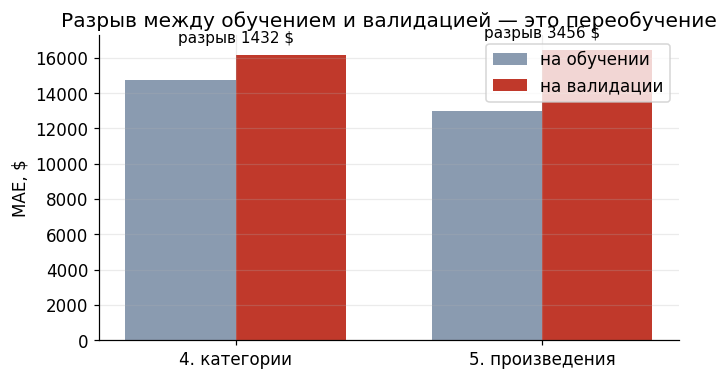

In [30]:
## ── считаем ────────────────────────────────────────────────────────
mae4_train = mean_absolute_error(y.loc[clean],
                                 np.exp(m4.predict(houses.loc[clean, NUM + CAT])))
# на каждый шаг — пара чисел: на обучении и на валидации
two_steps = [("4. категории", mae4_train, mae4),
             ("5. произведения", mae5_train, mae5)]
x = np.arange(len(two_steps))

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.bar(x - 0.18, [p[1] for p in two_steps], 0.36, color=GREY, label="на обучении")
ax.bar(x + 0.18, [p[2] for p in two_steps], 0.36, color=RED, label="на валидации")
for i, p in enumerate(two_steps):
    ax.annotate("разрыв %.0f $" % (p[2] - p[1]), (i, max(p[1], p[2])),
                xytext=(0, 8), textcoords="offset points", ha="center", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([p[0] for p in two_steps])
ax.set_ylabel("MAE, $")
ax.set_title("Разрыв между обучением и валидацией — это переобучение")
ax.legend()
plt.show()

## Шаг 6. Регуляризация, гиперпараметр и кросс-валидация

Выбрасывать 104 новых столбца жалко: среди них есть полезные. Вместо
этого придавим веса — на лекции это была «плата за большие веса»:

* `Ridge(alpha=...)` — та же линейная регрессия, но к ошибке, которую она
  минимизирует, добавлено ещё одно слагаемое: сумма квадратов весов,
  умноженная на `alpha`. Держать большой вес модели становится невыгодно,
  и вес столбца, который его не отрабатывает, прижимается к нулю.
  `alpha=0` — это обычная регрессия, чем больше `alpha`, тем сильнее
  штраф и тем ближе все веса к нулю. Столбцы при этом остаются на месте,
  ни один не выбрасывается — поэтому масштабирование и обязательно:
  без него штраф давил бы на столбцы неравномерно.

Сколько ставить в `alpha`, **никто не знает заранее** — это гиперпараметр,
его подбирают. Подберём двумя способами и сравним.

**Способ первый — по валидации.** Обучаем на обучающей части, меряем на
валидации, берём лучшее значение.

In [31]:
## ── функция: тот же конвейер, но с Ridge ───────────────────────────
def build_ridge(alpha):
    "Конвейер шага 5, но с Ridge вместо обычной регрессии."
    prep = ColumnTransformer([
        ("числа", Pipeline([("пропуски", SimpleImputer(strategy="median")),
                            ("произведения", PolynomialFeatures(degree=2, include_bias=False)),
                            ("масштаб", StandardScaler())]), NUM),
        ("категории", OneHotEncoder(handle_unknown="ignore"), CAT),
    ])
    return Pipeline([("подготовка", prep), ("модель", Ridge(alpha=alpha))])


## ── подбор alpha по валидации ──────────────────────────────────────
alphas = [0.3, 1, 3, 10, 30, 100, 300]
by_valid = []

for a in alphas:
    m = build_ridge(a)
    m.fit(houses.loc[clean, NUM + CAT], np.log(y.loc[clean]))
    pred = np.exp(m.predict(houses.loc[valid, NUM + CAT]))
    by_valid.append(mean_absolute_error(y.loc[valid], pred))

# argmin возвращает номер наименьшего элемента в списке
best_by_valid = alphas[int(np.argmin(by_valid))]

## ── числа ──────────────────────────────────────────────────────────
print("Подбор alpha по валидации:")
print("   лучшая alpha:                  %s" % best_by_valid)
print("   MAE на валидации с этой alpha: %s" % show(min(by_valid), "$"))
print("   а шаг 4 давал:                 %s" % show(mae4, "$"))
print("   то есть штраф выиграл:         %.1f %%" % (100 * (1 - min(by_valid) / mae4)))

Подбор alpha по валидации:
   лучшая alpha:                  3
   MAE на валидации с этой alpha: 15465.30 $
   а шаг 4 давал:                 16155.11 $
   то есть штраф выиграл:         4.3 %


По валидации выходит, что регуляризация обошла шаг 4 на 4,3 %.
Но валидация — это **одно** разбиение и всего 292 дома. Что если нам
просто повезло с этими 292 домами?

**Способ второй — кросс-валидация.** Обучающую часть делим на 5 кусков,
пять раз обучаем на четырёх и проверяем на пятом, а потом смотрим
среднее **и разброс** между кусками. Тест при этом по-прежнему закрыт.

Посчитаем её сами, циклом в пять проходов, — так видно, из чего метрика
складывается. Понадобятся две вещи:

* `KFold(5, shuffle=True, random_state=SEED)` — нарезка: метод `split`
  пять раз выдаёт номера строк «на чём учиться» и «на чём проверяться»,
  и каждая строка ровно один раз попадает в проверочный кусок;
* `clone(модель)` — необученная копия: настройки те же, обучения нет.
  Нужна, чтобы пять обучений на кусках не затёрли модель, обученную
  на всей обучающей части.

В sklearn есть и готовая `cross_val_score`, которая делает всё это одной
строкой. Здесь она неудобна: модель учится на логарифме цены, а ошибку мы
хотим видеть в долларах, — и цикл получается понятнее, чем настройка
готовой функции.

Считаем MAE по кускам для каждой `alpha` и для модели шага 4.

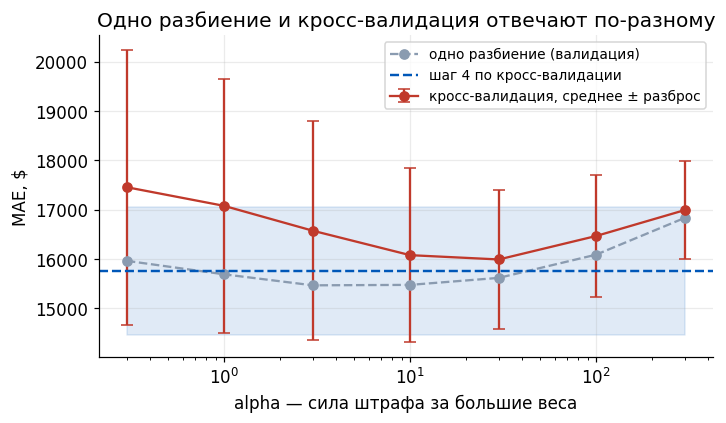

Кросс-валидация, 5 кусков обучающей части:
   шаг 4, без штрафа:                 MAE 15755.96 $ ± 1289.41 $
   лучшая alpha по кросс-валидации 30   MAE 15989.38 $ ± 1407.31 $
Шаг «6. + Ridge»: MAE на валидации = 15616.43 $
   на шаге «5. + произведения» было 16446.35 $ — стало лучше на 829.93 $


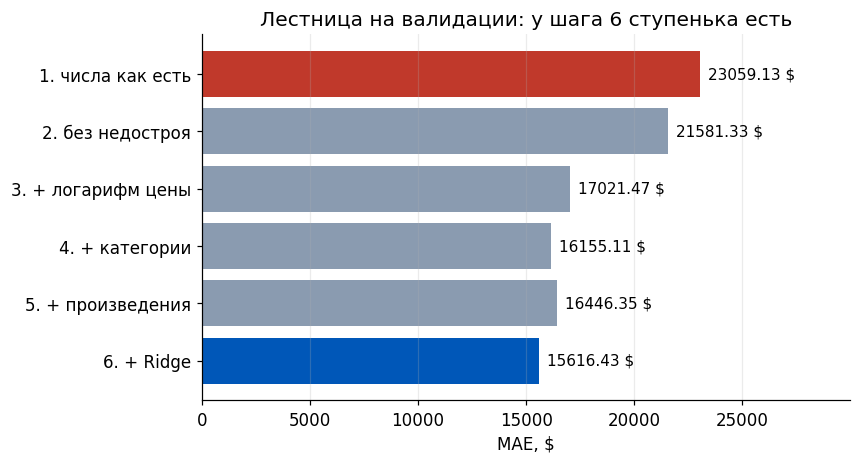

In [32]:
## ── функция: MAE по пяти кускам ────────────────────────────────────
cv = KFold(5, shuffle=True, random_state=SEED)
X_fit, y_fit = houses.loc[clean, NUM + CAT], y.loc[clean]


def mae_by_pieces(model):
    "Пять раз обучает модель на четырёх кусках и меряет MAE на пятом."
    out = []
    for learn, checkup in cv.split(X_fit):
        piece = clone(model)                 # копия, чтобы не портить исходную
        piece.fit(X_fit.iloc[learn], np.log(y_fit.iloc[learn]))
        pred = np.exp(piece.predict(X_fit.iloc[checkup]))
        out.append(mean_absolute_error(y_fit.iloc[checkup], pred))
    return np.array(out)


## ── кросс-валидация по alpha ───────────────────────────────────────
cv_mean, cv_std = [], []
for a in alphas:
    scores = mae_by_pieces(build_ridge(a))
    cv_mean.append(scores.mean())
    cv_std.append(scores.std())

base_scores = mae_by_pieces(m4)          # та же проверка для модели шага 4
best_by_cv = alphas[int(np.argmin(cv_mean))]

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots()
ax.errorbar(alphas, cv_mean, yerr=cv_std, fmt="o-", color=RED, capsize=4,
            label="кросс-валидация, среднее ± разброс")
ax.semilogx(alphas, by_valid, "o--", color=GREY, label="одно разбиение (валидация)")
ax.axhline(base_scores.mean(), color=BLUE, lw=1.6, ls="--", label="шаг 4 по кросс-валидации")
ax.fill_between([min(alphas), max(alphas)],
                base_scores.mean() - base_scores.std(),
                base_scores.mean() + base_scores.std(), color=BLUE, alpha=0.12)
ax.set_xlabel("alpha — сила штрафа за большие веса")
ax.set_ylabel("MAE, $")
ax.set_title("Одно разбиение и кросс-валидация отвечают по-разному")
ax.legend(fontsize=9)
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("Кросс-валидация, 5 кусков обучающей части:")
print("   шаг 4, без штрафа:                 MAE %s ± %s"
      % (show(base_scores.mean(), "$"), show(base_scores.std(), "$")))
print("   лучшая alpha по кросс-валидации %-4s MAE %s ± %s"
      % (best_by_cv, show(min(cv_mean), "$"), show(cv_std[int(np.argmin(cv_mean))], "$")))

## ── лучшая модель — на лестницу ────────────────────────────────────
m6 = build_ridge(best_by_cv)
m6.fit(X_fit, np.log(y_fit))
pred6 = np.exp(m6.predict(houses.loc[valid, NUM + CAT]))
mae6 = mean_absolute_error(y.loc[valid], pred6)
remember(LADDER, "6. + Ridge", mae6, "MAE", "$")
show_ladder(LADDER, "Лестница на валидации: у шага 6 ступенька есть")

О чём картинка? Серый пунктир — то, что говорило одно разбиение:
«регуляризация выигрывает». Красная линия с усами — кросс-валидация:
выигрыша **нет**, лучший Ridge попадает внутрь разброса шага 4, а сам
разброс между кусками (больше тысячи долларов) в несколько раз больше
разницы между моделями.

И два способа выбрали **разные** alpha — ещё один признак того, что
разница между ними несущественна.

На лестнице шаг 6 всё равно стоит ниже всех — потому что лестница
меряет на валидации, то есть ровно тем способом, который мы только что
поймали на обмане. Ступенька там есть, но она меньше разброса между
кусками кросс-валидации, и на шаге 7 тест это подтвердит.

Вывод: одному разбиению верить нельзя, и кросс-валидация нужна именно
для того, чтобы увидеть **разброс**, а не только среднее.

## Шаг 7. Открываем тест

Шесть шагов мы выбирали решения по обучающей части. Теперь один раз
проверимся на тесте — на данных, которых модель не видела.

In [33]:
## ── прогнозы трёх моделей на тесте ─────────────────────────────────
# модель шага 1 училась на цене в долларах, шаги 4 и 6 — на логарифме
pred_t1 = m1.predict(houses.loc[test, NUM])
pred_t4 = np.exp(m4.predict(houses.loc[test, NUM + CAT]))
pred_t6 = np.exp(m6.predict(houses.loc[test, NUM + CAT]))

## ── числа ──────────────────────────────────────────────────────────
print("Тест: %d домов, которых никто не видел" % len(test))
for name, p in (("шаг 1 — числа как есть", pred_t1),
                ("шаг 4 — после разбора данных", pred_t4),
                ("шаг 6 — со штрафом", pred_t6)):
    print("   %-30s MAE %12s   R² %s"
          % (name, show(mean_absolute_error(y.loc[test], p), "$"),
             show(r2_score(y.loc[test], p))))

print("\nЧто предсказала кросс-валидация:")
print("   шаги 4 и 6 на тесте различаются на:          %s"
      % show(abs(mean_absolute_error(y.loc[test], pred_t4)
                 - mean_absolute_error(y.loc[test], pred_t6)), "$"))
print("   а разброс между кусками кросс-валидации был: %s"
      % show(base_scores.std(), "$"))

Тест: 292 домов, которых никто не видел
   шаг 1 — числа как есть         MAE   24299.11 $   R² 0.7934
   шаг 4 — после разбора данных   MAE   15537.72 $   R² 0.9206
   шаг 6 — со штрафом             MAE   15913.01 $   R² 0.9193

Что предсказала кросс-валидация:
   шаги 4 и 6 на тесте различаются на:          375.29 $
   а разброс между кусками кросс-валидации был: 1289.41 $


Теперь про лестницу — её стоит прочитать внимательно. **Все её ступеньки
измерены на валидации**, то есть на 292 домах, которые модель не видела,
но по которым мы выбирали решения. Тест мы открыли только что, и на
второй картинке те же три модели стоят рядом на обеих выборках.

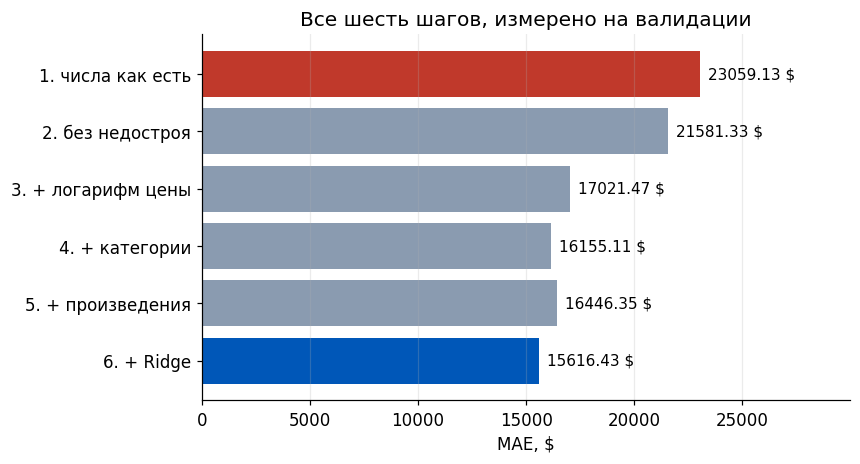

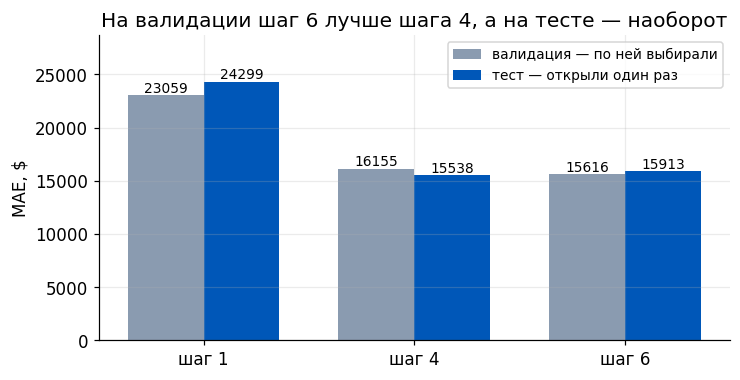

In [34]:
## ── лестница ───────────────────────────────────────────────────────
show_ladder(LADDER, "Все шесть шагов, измерено на валидации")

## ── считаем ────────────────────────────────────────────────────────
on_valid = [mae1, mae4, mae6]
on_test = [mean_absolute_error(y.loc[test], p) for p in (pred_t1, pred_t4, pred_t6)]
x = np.arange(3)

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.bar(x - 0.18, on_valid, 0.36, color=GREY, label="валидация — по ней выбирали")
ax.bar(x + 0.18, on_test, 0.36, color=BLUE, label="тест — открыли один раз")
for i in range(3):
    ax.text(x[i] - 0.18, on_valid[i], "%.0f" % on_valid[i], ha="center",
            va="bottom", fontsize=9)
    ax.text(x[i] + 0.18, on_test[i], "%.0f" % on_test[i], ha="center",
            va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(["шаг 1", "шаг 4", "шаг 6"])
ax.set_ylim(0, max(on_valid + on_test) * 1.18)
ax.set_ylabel("MAE, $")
ax.set_title("На валидации шаг 6 лучше шага 4, а на тесте — наоборот")
ax.legend(fontsize=9)
plt.show()

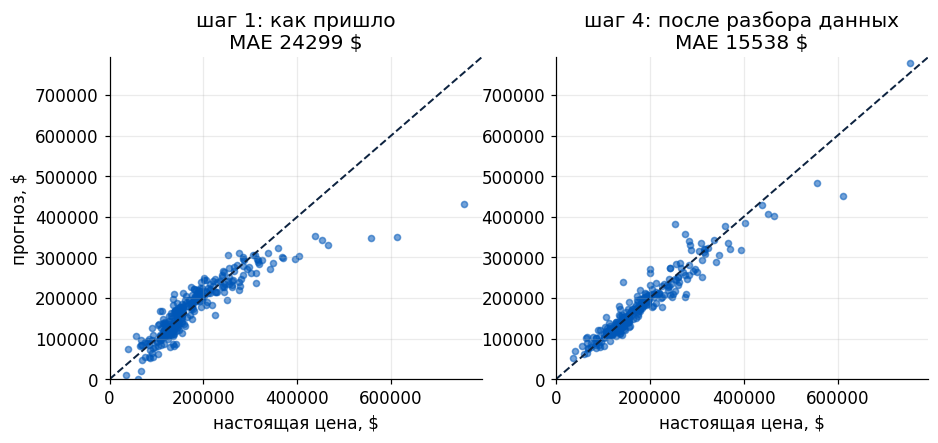

Итог на тесте: шаг 1 против шага 4
   ошибка упала на:                        36.1 %
   это в процентах от медианной цены дома: 9.5 %


In [35]:
## ── графики ────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.8))
lim = [0, y.loc[test].max() * 1.05]
for a, p, ttl in ((ax[0], pred_t1, "шаг 1: как пришло"),
                  (ax[1], pred_t4, "шаг 4: после разбора данных")):
    a.scatter(y.loc[test], p, s=16, color=BLUE, alpha=0.55)
    a.plot(lim, lim, color=INK, lw=1.3, ls="--")
    a.set_xlim(lim)
    a.set_ylim(lim)
    a.set_xlabel("настоящая цена, $")
    a.set_title("%s\nMAE %.0f $" % (ttl, mean_absolute_error(y.loc[test], p)))
ax[0].set_ylabel("прогноз, $")
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("Итог на тесте: шаг 1 против шага 4")
print("   ошибка упала на:                        %.1f %%"
      % (100 * (1 - mean_absolute_error(y.loc[test], pred_t4)
                / mean_absolute_error(y.loc[test], pred_t1))))
print("   это в процентах от медианной цены дома: %.1f %%"
      % (100 * mean_absolute_error(y.loc[test], pred_t4) / median_price))

## Итог первой части

Ошибка упала с 14 % до 9,5 % от цены дома, и **ни одного нового
алгоритма мы не применили** — всё время была одна и та же линейная
регрессия. Изменились только данные, которые мы ей давали.

В отчёт идёт модель шага 4: она не хуже сложной, но в ней 48 столбцов
вместо 139 и нет гиперпараметров. **При равном качестве выбирают
более простую модель.**

Что сказать банку: для предварительного отбора объектов модели достаточно,
для окончательной оценки залога нужно больше бизнес-аналитики.

---
# Часть 2. Кредитный скоринг: выдавать ли кредит

**Ситуация.** В банк приходит заявка на кредит. Решение принимается
до выдачи, поэтому опираться можно только на анкету и кредитную историю.
Модель должна оценить вероятность того, что заёмщик уйдёт в серьёзную
просрочку в следующие два года.

**Метрика — ROC-AUC**, а окончательное решение принимаем по деньгам.

**Экономика** (в жизни эти числа даёт риск-менеджмент):

* кредит выдан и **вернулся** — банк зарабатывает **3 %** от суммы;
* кредит выдан и **ушёл в дефолт** — банк теряет **50 %** от суммы;
* в выдаче отказано — ноль в обе стороны.

Сумму считаем как **три месячных дохода** заявителя.

**Данные.** Набор Give Me Some Credit: 150 000 заявок, 10 признаков
и отметка о дефолте. Первоисточник — тот же openml.org (`GiveMeSomeCredit`,
[openml.org/d/46929](https://www.openml.org/d/46929); источник — одноимённое
соревнование Kaggle 2011 года), а в репозитории курса лежит готовый файл.
Подготовка здесь была проще, чем с домами: все столбцы и так числовые,
поэтому названия переведены на русский, ответ из слов `Yes` и `No` записан
единицей и нулём, а из 150 000 заявок взята подвыборка на 40 000 — с той же
долей дефолтов, что в исходных данных, чтобы всё считалось за секунды.
Ничего не чистили — и, как увидите, чистить тут есть что.

Метрику ROC-AUC разберём на картинках сразу после первого обучения:
там же объясним, почему для этой задачи она подходит, а accuracy нет.

In [ ]:
## ── данные ─────────────────────────────────────────────────────────
CREDIT = ("https://raw.githubusercontent.com/Rimest/ml_ai_course_gsb_hse"
          "/main/data/credit_scoring.csv")
credit = pd.read_csv(CREDIT)
default = credit["дефолт"]        # ответ: 1 — заёмщик ушёл в дефолт

## ── числа ──────────────────────────────────────────────────────────
print("Заявок: %d, столбцов про каждую: %d" % credit.shape)
print("из них ушли в дефолт: %d (%.1f %%)" % (default.sum(), 100 * default.mean()))

credit.head()

| Столбец | Что это |
|---|---|
| `дефолт` | 1 — серьёзная просрочка в следующие два года. **Это ответ** |
| `загрузка_лимитов` | какую долю доступных лимитов человек уже использует |
| `возраст` | лет |
| `просрочек_30_59`, `просрочек_60_89`, `просрочек_90` | сколько раз допускал просрочку такой длительности |
| `долг_к_доходу` | отношение всех платежей к доходу |
| `доход_в_месяц` | заявленный доход |
| `открытых_кредитов` | сколько кредитов и кредиток открыто |
| `ипотек` | сколько кредитов под залог недвижимости |
| `иждивенцев` | сколько человек на содержании |

## Шаг 0. Опять отдаём как есть

In [38]:
## ── пробуем обучить как есть ───────────────────────────────────────
try:
    LogisticRegression().fit(credit.drop(columns=["дефолт"]), default)
except Exception as e:
    print("Не обучилась:", type(e).__name__)
    print(str(e)[:160])

## ── где пропуски ───────────────────────────────────────────────────
cgaps = credit.isna().sum()
cgaps = cgaps[cgaps > 0].sort_values(ascending=False)
print("\nВ каком столбце пусто:")
for name, n in cgaps.items():
    print("   %-15s пустых клеток %d — это %.0f %% заявок"
          % (name, n, 100 * n / len(credit)))

Не обучилась: ValueError
Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ens

В каком столбце пусто:
   доход_в_месяц   пустых клеток 7883 — это 20 % заявок
   иждивенцев      пустых клеток 1064 — это 3 % заявок


Здесь все столбцы числовые, поэтому причина одна — пропуски: доход не
указан у каждого пятого заявителя, число иждивенцев — у каждого сорокового.

Самое простое, что можно сделать, — отложить эти два столбца в сторону
и начать с остальных восьми.

Сколько заявок в какой части:
   обучение — на нём модель подбирает веса    заявок 24000, из них дефолтов 1604
   валидация — на ней сравниваем шаги         заявок  8000, из них дефолтов 535
   тест — откроем один раз в самом конце      заявок  8000, из них дефолтов 535


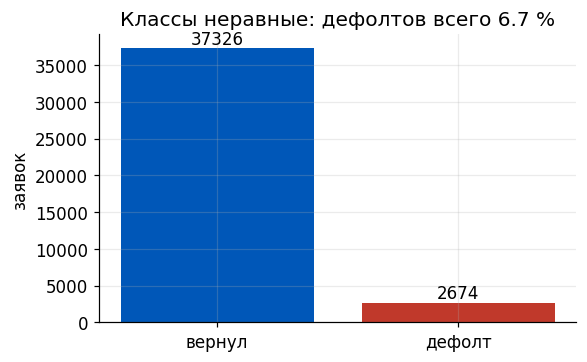

In [39]:
## ── делим заявки на три части ──────────────────────────────────────
# stratify следит, чтобы доля дефолтов во всех трёх частях была одинаковой
# делим заявки на обучение 60 %, валидацию 20 % и тест 20 %
fit, ctest = train_test_split(credit.index, test_size=0.2,
                              random_state=SEED, stratify=default)
ctrain, cvalid = train_test_split(fit, test_size=0.25, random_state=SEED,
                                  stratify=default.loc[fit])

print("Сколько заявок в какой части:")
for name, part in (("обучение — на нём модель подбирает веса", ctrain),
                   ("валидация — на ней сравниваем шаги", cvalid),
                   ("тест — откроем один раз в самом конце", ctest)):
    print("   %-42s заявок %5d, из них дефолтов %d"
          % (name, len(part), default.loc[part].sum()))

## ── лестница и список столбцов ─────────────────────────────────────
CLADDER = []
BASE = ["загрузка_лимитов", "возраст", "просрочек_30_59", "просрочек_60_89",
        "просрочек_90", "долг_к_доходу", "открытых_кредитов", "ипотек"]

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.bar(["вернул", "дефолт"], [(default == 0).sum(), (default == 1).sum()],
       color=[BLUE, RED])
ax.set_ylabel("заявок")
ax.set_title("Классы неравные: дефолтов всего %.1f %%" % (100 * default.mean()))
for i, v in enumerate([(default == 0).sum(), (default == 1).sum()]):
    ax.text(i, v, "%d" % v, ha="center", va="bottom")
plt.show()

## Шаг 1. Восемь столбцов без пропусков

Конвейер здесь тот же, что в первой части, — пропуски, масштаб, модель, —
меняется только последний этап:

* `LogisticRegression(max_iter=3000)` — складывает вклады признаков точно
  так же, как линейная регрессия, но сумму прогоняет через логистическую
  функцию с лекции, и на выходе получается вероятность от 0 до 1, а не
  доллары. Веса подбираются градиентным спуском, и `max_iter` — сколько
  шагов ему разрешено сделать: 3000 взято с запасом, чтобы спуск успел
  дойти до минимума и не пришлось читать предупреждение, что он
  не сошёлся.

Обучим её на восьми столбцах и посчитаем ROC-AUC и accuracy на валидации.
Сравним accuracy с «моделью», которая всем говорит «вернёт».

In [40]:
## ── обучение ───────────────────────────────────────────────────────
c1 = Pipeline([
    ("пропуски", SimpleImputer(strategy="median")),
    ("масштаб", StandardScaler()),
    ("модель", LogisticRegression(max_iter=3000)),
])
c1.fit(credit.loc[ctrain, BASE], default.loc[ctrain])

## ── качество на валидации ──────────────────────────────────────────
# predict_proba выдаёт две вероятности на каждую заявку: «вернёт» и «дефолт».
# Второй столбец [:, 1] — вероятность дефолта, она нам и нужна
p1 = c1.predict_proba(credit.loc[cvalid, BASE])[:, 1]
# roc_auc_score меряет, насколько верно модель упорядочила заявки по риску
auc1 = roc_auc_score(default.loc[cvalid], p1)

print("Шаг 1 на валидации:")
print("   ROC-AUC модели:  %s" % show(auc1))
# accuracy_score — доля верных ответов, если считать дефолтом всё выше 0,5
print("   accuracy модели: %s" % show(accuracy_score(default.loc[cvalid], p1 > 0.5)))
print("   accuracy «модели», которая всем говорит «вернёт»: %s"
      % show(1 - default.loc[cvalid].mean()))
remember(CLADDER, "1. восемь столбцов", auc1, "ROC-AUC", lower_better=False)

Шаг 1 на валидации:
   ROC-AUC модели:  0.6845
   accuracy модели: 0.9345
   accuracy «модели», которая всем говорит «вернёт»: 0.9331
Шаг «1. восемь столбцов»: ROC-AUC на валидации = 0.6845


0.6845443221012701

Два числа посчитаны, и они говорят разное: accuracy у модели и у пустышки
почти одинаковая, а AUC хоть что-то показывает. Прежде чем идти дальше,
разберёмся, что эти метрики меряют — на картинках.

## Отступление: accuracy и ROC-AUC на пальцах

**Accuracy — доля верных ответов.** Модель обязана сказать про каждую
заявку «вернёт» или «не вернёт», а мы считаем, сколько раз она угадала.
Нарисуем сто заявок такими, какие они приходят в банк.

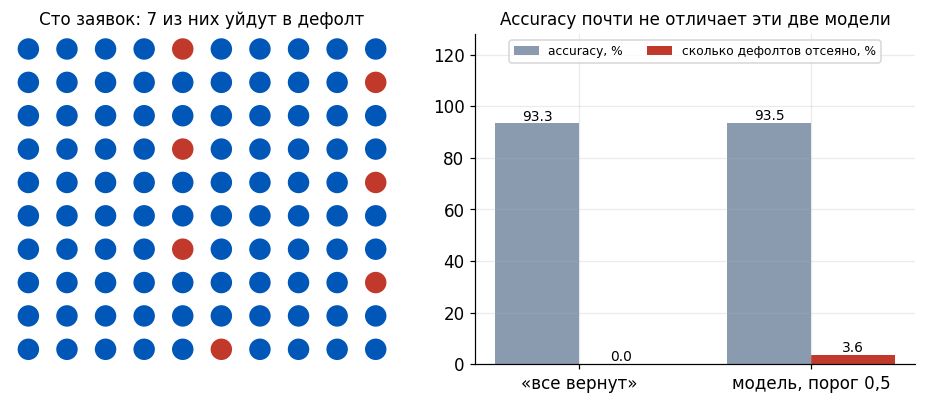

Что делают две модели на 8000 заявках:
   «все вернут»:             отказов 0, дефолтов среди них 0 из 535
   модель шага 1, порог 0,5: отказов 27, дефолтов среди них 19 из 535


In [41]:
## ── считаем ────────────────────────────────────────────────────────
# на сто заявок приходится столько дефолтов
per_100 = 100 * default.loc[cvalid].mean()
# confusion_matrix: строки — что было на самом деле, столбцы — что решила модель
cm1 = confusion_matrix(default.loc[cvalid], p1 > 0.5)
caught = cm1[1, 1] / cm1[1].sum()          # какую долю дефолтов модель отсекла

## ── графики ────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(10.6, 3.9),
                       gridspec_kw={"width_ratios": [1, 1.15]})

bad = int(round(per_100))
spots = np.linspace(4, 95, bad).astype(int)      # где нарисуем дефолты
kind = np.zeros(100, dtype=int)
kind[spots] = 1
ax[0].scatter(np.arange(100) % 10, -(np.arange(100) // 10), s=170,
              color=[RED if k else BLUE for k in kind])
ax[0].set_title("Сто заявок: %d из них уйдут в дефолт" % bad, fontsize=11)
ax[0].axis("off")

x = np.arange(2)
ax[1].bar(x - 0.18, [100 * (1 - default.loc[cvalid].mean()),
                     100 * accuracy_score(default.loc[cvalid], p1 > 0.5)],
          0.36, color=GREY, label="accuracy, %")
ax[1].bar(x + 0.18, [0, 100 * caught], 0.36, color=RED,
          label="сколько дефолтов отсеяно, %")
for i, v in enumerate([100 * (1 - default.loc[cvalid].mean()),
                       100 * accuracy_score(default.loc[cvalid], p1 > 0.5)]):
    ax[1].text(i - 0.18, v, "%.1f" % v, ha="center", va="bottom", fontsize=9)
for i, v in enumerate([0, 100 * caught]):
    ax[1].text(i + 0.18, v, "%.1f" % v, ha="center", va="bottom", fontsize=9)
ax[1].set_xticks(x)
ax[1].set_xticklabels(["«все вернут»", "модель, порог 0,5"])
ax[1].set_ylim(0, 128)
ax[1].set_title("Accuracy почти не отличает эти две модели", fontsize=11)
ax[1].legend(fontsize=8, loc="upper center", ncol=2)
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("Что делают две модели на %d заявках:" % len(cvalid))
print("   «все вернут»:             отказов 0, дефолтов среди них 0 из %d"
      % cm1[1].sum())
print("   модель шага 1, порог 0,5: отказов %d, дефолтов среди них %d из %d"
      % (cm1[:, 1].sum(), cm1[1, 1], cm1[1].sum()))

Пустышка, которая всем говорит «вернёт», угадывает 93 заявки из ста —
просто потому, что в данных 93 надёжных заёмщика на семь дефолтов.
Наша модель набирает те же 93 %, хотя ведёт себя совсем иначе: на пороге
0,5 она отказывает 27 заявителям, и 19 из них — настоящие дефолты.

Вот и вывод: accuracy не различает «модель, которая не делает ничего»
и «модель, которая кое-что находит». При дисбалансе она меряет в основном
то, сколько в данных хороших заёмщиков.

**ROC-AUC меряет порядок.** Модель выдаёт не «да/нет», а число — оценку
риска. Выстроим заявки по этой оценке: слева те, кому модель доверяет
больше всех, справа — кому меньше всех. Красные — те, кто ушёл в дефолт.
Хорошая модель собирает красные справа.

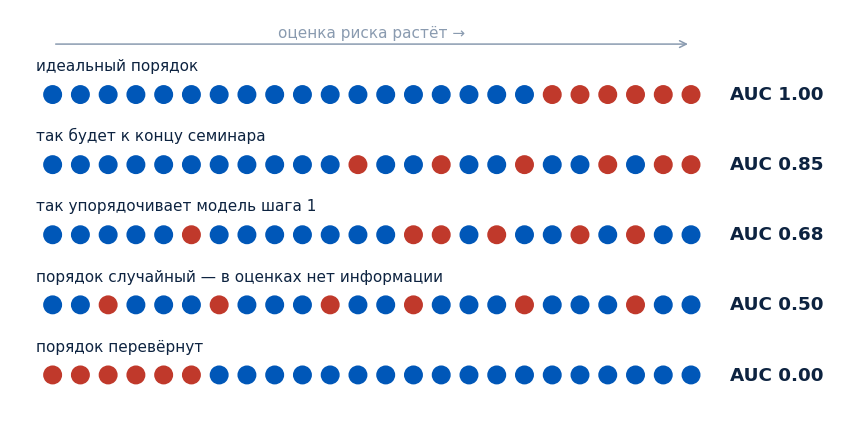

Та же величина в двух шкалах:
   ROC-AUC модели шага 1:           0.6845
   коэффициент Джини = 2 · AUC − 1: 0.3691


In [42]:
## ── пять вариантов порядка ─────────────────────────────────────────
ROWS = [("идеальный порядок", [18, 19, 20, 21, 22, 23]),
        ("так будет к концу семинара", [11, 14, 17, 20, 22, 23]),
        ("так упорядочивает модель шага 1", [5, 13, 14, 16, 19, 21]),
        ("порядок случайный — в оценках нет информации", [2, 6, 10, 13, 17, 21]),
        ("порядок перевёрнут", [0, 1, 2, 3, 4, 5])]

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9.8, 4.8))
for row, (name, reds) in enumerate(ROWS):
    labels = np.zeros(24, dtype=int)
    labels[reds] = 1
    # оценка модели = место в ряду, поэтому AUC считается прямо по позициям
    auc = roc_auc_score(labels, np.arange(24))
    ax.scatter(np.arange(24), np.full(24, -row), s=130,
               color=[RED if t else BLUE for t in labels])
    ax.text(-0.6, -row + 0.34, name, fontsize=10, color=INK)
    ax.text(24.4, -row, "AUC %.2f" % auc, va="center", fontsize=12,
            fontweight="bold", color=INK)
ax.annotate("", (23, 0.72), (0, 0.72), arrowprops=dict(arrowstyle="->", color=GREY))
ax.text(11.5, 0.82, "оценка риска растёт →", ha="center", fontsize=10, color=GREY)
ax.set_xlim(-1.5, 28.6)
ax.set_ylim(-4.6, 1.2)
ax.axis("off")
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("Та же величина в двух шкалах:")
print("   ROC-AUC модели шага 1:           %s" % show(auc1))
print("   коэффициент Джини = 2 · AUC − 1: %s" % show(2 * auc1 - 1))

**Что именно считает AUC.** Возьмите случайного дефолтника и случайного
надёжного заёмщика. AUC — это вероятность того, что дефолтник получил
оценку выше. В первом ряду это верно всегда: AUC = 1. В четвёртом ряду
порядок случайный, дефолтник оказывается выше надёжного ровно в половине
случаев: AUC = 0,5. Третий ряд — это наша сегодняшняя модель: красные
уже сдвинуты вправо, но перемешаны с синими.

Поэтому «дно» метрики — не ноль, а **половина**: 0,5 означает, что в оценках
модели нет никакой информации, это буквально как принимать решение о выдаче
кредита подбрасыванием монетки. А ноль — это не «хуже некуда», это
перевёрнутая модель: ***не вернёт кредит*** поменяли на ***вернёт кредит***.
Ниже 0,5 модели не опускаются — такую просто «переворачивают».

**Почему AUC годится здесь, при дисбалансе 1 к 14.** Опасение
обоснованное: AUC действительно бывает обманчив, когда редкий класс —
доли процента, потому что в его знаменателе все надёжные заёмщики,
и сотня лишних отказов среди сорока тысяч заявок метрику почти
не двигает. И если бы нам был нужен короткий список «двадцать самых
рискованных, проверить вручную», смотреть надо было бы на точность
в этих двадцати (precision@k) или на PR-AUC.

Здесь AUC подходит по трём причинам:

1. **Он не зависит от доли дефолтов.** AUC считает только порядок:
   продублируйте всех надёжных заёмщиков — accuracy и точность
   изменятся, а AUC останется тем же. Нам как раз нужно сравнивать
   шаги друг с другом, а не оценивать абсолютную выгоду.
2. **Дисбаланс умеренный, и дефолтов много** — 2674 штуки. Беда
   «редкого класса» начинается там, где событий десятки.
3. **Это язык скоринга.** В банке качество скоринговой модели называют
   коэффициентом Джини, а он равен 2 · AUC − 1 — тот же AUC,
   пересчитанный в шкалу «0 — монетка, 1 — идеал». Так что да, мотивация
   именно такая: AUC и Джини — одно число в двух шкалах.

Дисклеймер: AUC меряет порядок и ничего не знает о том, сколько стоит
ошибка. Решение «выдавать или нет» мы примем на шаге 6 — деньгами.

AUC 0,68 — слабо: для скоринга это нижняя граница качества модели. Идём
разбираться с данными.

## Шаг 2. Абсурдные значения

Первое, что стоит сделать с числовыми столбцами, — посмотреть, в каких
пределах они меняются. Единицы у них разные (доли, годы, штуки,
отношения), поэтому нарисуем их на одной картинке в сжатой шкале:
каждое деление вправо — в десять раз больше.

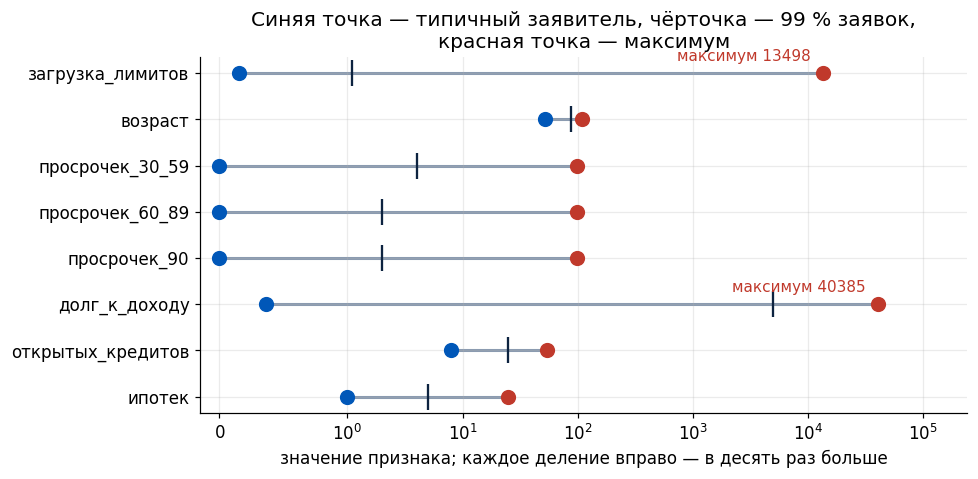

столбец                 медиана   99 % заявок ниже     максимум
загрузка_лимитов         0.1524             1.0897     13498.00
возраст                   52.00              87.00       109.00
просрочек_30_59          0.0000             4.0000        98.00
просрочек_60_89          0.0000             2.0000        98.00
просрочек_90             0.0000             2.0000        98.00
долг_к_доходу            0.3682            4969.05     40385.00
открытых_кредитов        8.0000              25.00        54.00
ипотек                   1.0000             5.0000        25.00


In [43]:
## ── считаем разброс ────────────────────────────────────────────────
# quantile(0.99) — значение, ниже которого лежат 99 % заявок
spread = pd.DataFrame({"медиана": credit[BASE].median(),
                       "99 %": credit[BASE].quantile(0.99),
                       "максимум": credit[BASE].max()})

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9.0, 4.2))
for i, col in enumerate(BASE):
    mid, hi = spread.loc[col, "медиана"], spread.loc[col, "максимум"]
    ax.plot([mid, hi], [i, i], color=GREY, lw=2, zorder=1)
    ax.scatter(mid, i, color=BLUE, s=80, zorder=3)
    ax.scatter(spread.loc[col, "99 %"], i, color=INK, marker="|", s=280, zorder=3)
    ax.scatter(hi, i, color=RED, s=80, zorder=3)
    if hi > 500:
        ax.annotate("максимум %.0f" % hi, (hi, i), xytext=(-8, 8),
                    textcoords="offset points", ha="right", color=RED, fontsize=10)
ax.set_yticks(range(len(BASE)))
ax.set_yticklabels(BASE)
ax.invert_yaxis()
# symlog — сжатая шкала: около нуля обычная, дальше каждое деление в 10 раз
ax.set_xscale("symlog", linthresh=1)
ax.set_xlim(-0.15, credit[BASE].max().max() * 6)
ax.set_xlabel("значение признака; каждое деление вправо — в десять раз больше")
ax.set_title("Синяя точка — типичный заявитель, чёрточка — 99 % заявок,\n"
             "красная точка — максимум")
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("%-20s %10s %18s %12s"
      % ("столбец", "медиана", "99 % заявок ниже", "максимум"))
for col in BASE:
    print("%-20s %10s %18s %12s"
          % (col, show(spread.loc[col, "медиана"]), show(spread.loc[col, "99 %"]),
             show(spread.loc[col, "максимум"])))

Картинка сразу делит столбцы на три группы.

**Спокойные** — возраст, открытых кредитов, ипотек: максимум у них того
же порядка, что и значение, ниже которого лежат 99 % заявок (109 против
87 лет, 54 против 25 кредитов). Такие столбцы можно брать как есть.

**Уехавшие на четыре порядка вправо** — `загрузка_лимитов`
и `долг_к_доходу`. И это ровно те два столбца, у которых по смыслу есть
предел:

* `загрузка_лимитов` — **доля** использованного лимита. Значение 0,15
  у типичного заявителя значит «использовал 15 % доступных лимитов».
  Выше единицы такая доля почти не поднимается, а в данных максимум —
  **13 498**.
* `долг_к_доходу` — **отношение** ежемесячных платежей по кредитам
  к месячному доходу. Типичное значение 0,37 значит «платежи съедают
  37 % дохода». Максимум в данных — **40 385**, то есть платежи будто бы
  в сорок тысяч раз больше дохода. Человек с таким отношением должен
  отдавать всю зарплату по кредитам три тысячи лет.

**Подозрительно одинаковые** — у всех трёх счётчиков просрочек максимум
ровно 98, хотя 99 % заявителей не переходят за две-четыре просрочки.
Три разных столбца с одинаковым максимумом — это не совпадение;
разберёмся с ними на следующем шаге.

Сейчас возьмёмся за первую пару. Посмотрим на их гистограммы, а потом —
кто эти люди.

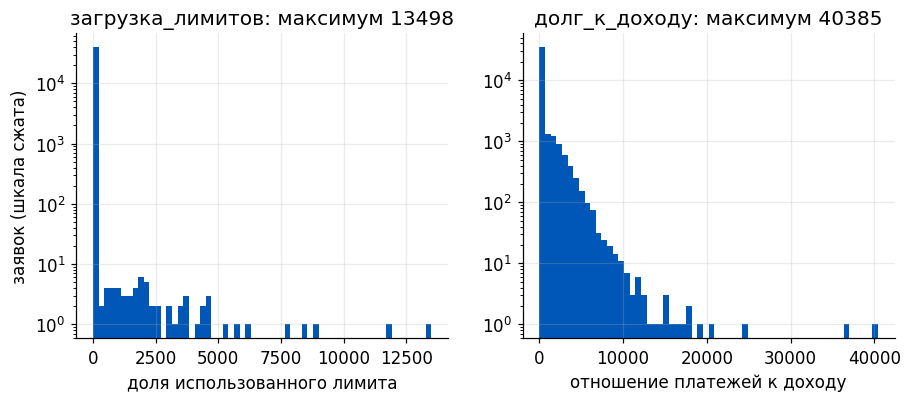

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.6))
ax[0].hist(credit["загрузка_лимитов"], bins=60, color=BLUE)
ax[0].set_yscale("log")
ax[0].set_title("загрузка_лимитов: максимум %.0f" % credit["загрузка_лимитов"].max())
ax[0].set_xlabel("доля использованного лимита")
ax[1].hist(credit["долг_к_доходу"], bins=60, color=BLUE)
ax[1].set_yscale("log")
ax[1].set_title("долг_к_доходу: максимум %.0f" % credit["долг_к_доходу"].max())
ax[1].set_xlabel("отношение платежей к доходу")
ax[0].set_ylabel("заявок (шкала сжата)")
plt.show()

Гистограммы говорят одно и то же: почти все заявки сидят в узком левом
столбике, а дальше — пусто, и где-то далеко справа одиночные значения.
Именно так выглядят данные с абсурдными выбросами.

Теперь разберёмся, **почему** сорок тысяч — это плохо. Посмотрим,
у кого встречаются такие значения.

In [45]:
## ── считаем ────────────────────────────────────────────────────────
odd_ratio = credit["долг_к_доходу"] > 100

odd_income = credit.loc[odd_ratio, "доход_в_месяц"]

## ── числа ──────────────────────────────────────────────────────────
print("Откуда берутся сорок тысяч:")
print("   заявок с отношением долга к доходу больше 100: %d — это %.0f %% всех заявок"
      % (odd_ratio.sum(), 100 * odd_ratio.mean()))
print("   из них доход не указан:  %d — это %.0f %% таких заявок"
      % (odd_income.isna().sum(), 100 * odd_income.isna().mean()))
print("   из них доход равен нулю: %d — это %.0f %% таких заявок"
      % ((odd_income == 0).sum(), 100 * (odd_income == 0).mean()))
print("   медиана отношения у остальных заявок: %s"
      % show(credit.loc[~odd_ratio, "долг_к_доходу"].median()))

Откуда берутся сорок тысяч:
   заявок с отношением долга к доходу больше 100: 6495 — это 16 % всех заявок
   из них доход не указан:  6059 — это 93 % таких заявок
   из них доход равен нулю: 316 — это 5 % таких заявок
   медиана отношения у остальных заявок: 0.3029


Вот и ответ: почти у всех этих заявителей **доход неизвестен или равен
нулю**. Делить было не на что, и в поле «отношение долга к доходу»
оказалась сама сумма платежей в долларах. То есть в 16 % строк
в этом столбце лежит вообще другая величина — не отношение, а деньги.

**Чем это плохо для линейной модели.** Вспомните `StandardScaler`
из первой части: он делит столбец на его разброс, а разброс считается
по всем значениям — вместе с этими сорока тысячами. После деления все
нормальные заявки сжимаются в точку у нуля: разница между заёмщиком
с загрузкой лимитов 5 % и заёмщиком с загрузкой 90 % на фоне
тринадцати тысяч просто исчезает, для модели это одно и то же число.
Один мусорный выброс обесценивает весь столбец.

Лечение простое: **обрезать** хвост на разумном уровне. `clip(upper=2)`
заменяет всё, что больше двух, на двойку — и столбец снова про дело:
«загрузка лимитов 200 % и больше», а насколько именно больше, модели
знать незачем, там всё равно мусор. Отношение долга к доходу так же
обрежем на 3.

Заметьте, чего мы **не** делаем: не выбрасываем заявки и не удаляем
столбец. Строки остаются на месте, в них гаснут только абсурдные
значения.

Обрезаем оба столбца и обучаем модель заново.

Шаг 2: ROC-AUC на валидации 0.7997 (на шаге 1 было 0.6845)
Шаг «2. обрезали абсурд»: ROC-AUC на валидации = 0.7997
   на шаге «1. восемь столбцов» было 0.6845 — стало лучше на 0.1151


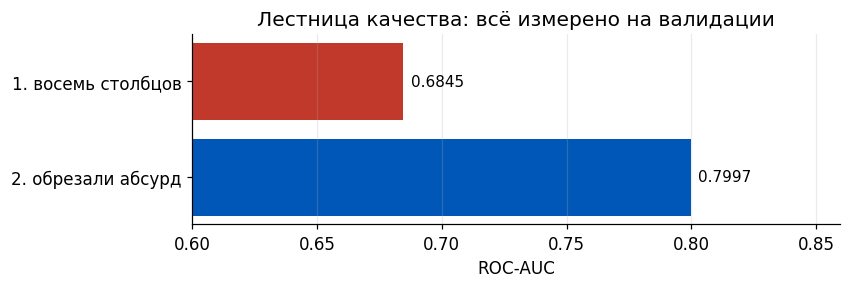

In [46]:
## ── обрезаем абсурдные значения ────────────────────────────────────
# copy делает отдельную таблицу, чтобы исходные данные остались нетронутыми
fixed = credit.copy()
# clip(upper=2): всё, что больше двух, становится двойкой
fixed["загрузка_лимитов"] = credit["загрузка_лимитов"].clip(upper=2)
fixed["долг_к_доходу"] = credit["долг_к_доходу"].clip(upper=3)

## ── обучение ───────────────────────────────────────────────────────
c2 = Pipeline([
    ("пропуски", SimpleImputer(strategy="median")),
    ("масштаб", StandardScaler()),
    ("модель", LogisticRegression(max_iter=3000)),
])
c2.fit(fixed.loc[ctrain, BASE], default.loc[ctrain])

## ── качество на валидации ──────────────────────────────────────────
p2 = c2.predict_proba(fixed.loc[cvalid, BASE])[:, 1]
auc2 = roc_auc_score(default.loc[cvalid], p2)

print("Шаг 2: ROC-AUC на валидации %s (на шаге 1 было %s)"
      % (show(auc2), show(auc1)))
remember(CLADDER, "2. обрезали абсурд", auc2, "ROC-AUC", lower_better=False)
show_ladder(CLADDER, "Лестница качества: всё измерено на валидации",
            lower_better=False, start=0.6)

Плюс одиннадцать пунктов AUC за две строки кода — и это не новая
модель, а исправление данных.

## Шаг 3. Служебные коды вместо чисел

Теперь посмотрим на счётчики просрочек. Сколько раз человек может
допустить просрочку?

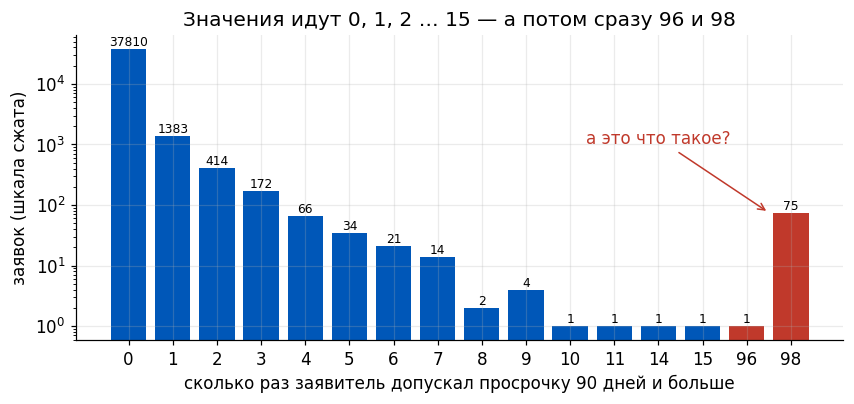

In [47]:
## ── считаем ────────────────────────────────────────────────────────
# value_counts считает, сколько раз встретилось каждое значение,
# sort_index упорядочивает по самому значению, а не по частоте
counts = credit["просрочек_90"].value_counts().sort_index()

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9.0, 3.6))
ax.bar(range(len(counts)), counts.values,
       color=[RED if v >= 90 else BLUE for v in counts.index])
ax.set_yscale("log")        # иначе на фоне 37 810 нулей остального не видно
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([str(int(v)) for v in counts.index])
for i, v in enumerate(counts.values):
    ax.text(i, v, "%d" % v, ha="center", va="bottom", fontsize=8)
ax.annotate("а это что такое?", (len(counts) - 1.5, counts.values[-1]),
            xytext=(-25, 45), textcoords="offset points", ha="right",
            color=RED, fontsize=11,
            arrowprops=dict(arrowstyle="->", color=RED))
ax.set_xlabel("сколько раз заявитель допускал просрочку 90 дней и больше")
ax.set_ylabel("заявок (шкала сжата)")
ax.set_title("Значения идут 0, 1, 2 … 15 — а потом сразу 96 и 98")
plt.show()

Значения идут 0, 1, 2 … 15, а потом внезапно **96 и 98**. Девяносто
восемь просрочек по 90 дней за два года физически невозможно: это
**служебные коды**, которыми в исходной системе помечали особые случаи
(нет данных, счёт закрыт и тому подобное).

Для модели это катастрофа: она считает 98 просто очень большим числом
и тянет вес признака в его сторону. Посмотрим, что за люди под этим кодом.

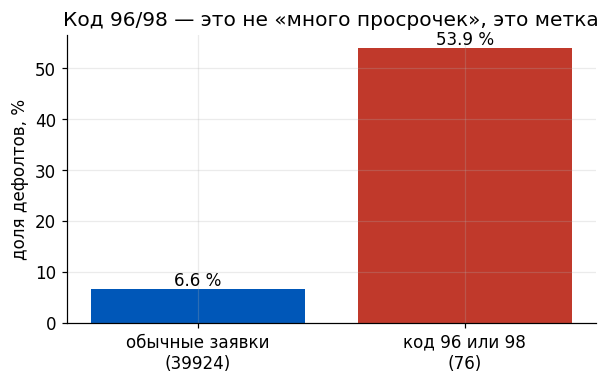

Что за люди под служебным кодом:
   обычные заявки:           39924, доля дефолтов 6.6 %
   заявки с кодом 96 или 98:    76, доля дефолтов 53.9 %


In [48]:
## ── считаем ────────────────────────────────────────────────────────
weird = credit["просрочек_90"] >= 96

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.bar(["обычные заявки\n(%d)" % (~weird).sum(), "код 96 или 98\n(%d)" % weird.sum()],
       [100 * default[~weird].mean(), 100 * default[weird].mean()], color=[BLUE, RED])
ax.set_ylabel("доля дефолтов, %")
ax.set_title("Код 96/98 — это не «много просрочек», это метка")
for i, v in enumerate([100 * default[~weird].mean(), 100 * default[weird].mean()]):
    ax.text(i, v, "%.1f %%" % v, ha="center", va="bottom")
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("Что за люди под служебным кодом:")
print("   обычные заявки:           %5d, доля дефолтов %.1f %%"
      % ((~weird).sum(), 100 * default[~weird].mean()))
print("   заявки с кодом 96 или 98: %5d, доля дефолтов %.1f %%"
      % (weird.sum(), 100 * default[weird].mean()))

Больше половины таких заявителей уходит в дефолт против 6,6 % у
остальных. То есть метка очень полезна — но пользоваться ею надо как
меткой, а не как числом.

Делаем две вещи: сами значения 96 и 98 заменяем на пропуск (его заполнит
медиана), а факт наличия кода выносим в отдельный столбец из нулей
и единиц.

Делаем флаг `странные_коды` и убираем значения 96 и 98 из трёх
счётчиков.

Шаг 3: ROC-AUC на валидации 0.8501 (на шаге 2 было 0.7997)
Шаг «3. коды 96/98 → метка»: ROC-AUC на валидации = 0.8501
   на шаге «2. обрезали абсурд» было 0.7997 — стало лучше на 0.0505


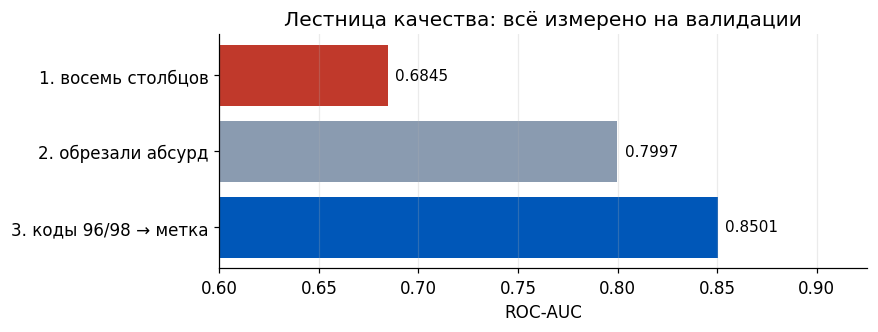

In [49]:
## ── чиним столбцы просрочек ────────────────────────────────────────
PAST_DUE = ["просрочек_30_59", "просрочек_60_89", "просрочек_90"]

# astype(int) превращает True/False в 1/0
fixed["странные_коды"] = (credit["просрочек_90"] >= 96).astype(int)
for col in PAST_DUE:
    # where оставляет значение там, где условие верно, а остальное делает пропуском
    fixed[col] = credit[col].where(credit[col] < 90)

BASE3 = BASE + ["странные_коды"]

## ── обучение ───────────────────────────────────────────────────────
c3 = Pipeline([
    ("пропуски", SimpleImputer(strategy="median")),
    ("масштаб", StandardScaler()),
    ("модель", LogisticRegression(max_iter=3000)),
])
c3.fit(fixed.loc[ctrain, BASE3], default.loc[ctrain])

## ── качество на валидации ──────────────────────────────────────────
p3 = c3.predict_proba(fixed.loc[cvalid, BASE3])[:, 1]
auc3 = roc_auc_score(default.loc[cvalid], p3)

print("Шаг 3: ROC-AUC на валидации %s (на шаге 2 было %s)"
      % (show(auc3), show(auc2)))
remember(CLADDER, "3. коды 96/98 → метка", auc3, "ROC-AUC", lower_better=False)
show_ladder(CLADDER, "Лестница качества: всё измерено на валидации",
            lower_better=False, start=0.6)

Ещё плюс пять пунктов. Обратите внимание: **мы не добавили никакой новой
информации** — она всё время лежала в данных. Мы только объяснили модели,
что 98 — это не число.

## Шаг 4. Возвращаем пропущенные столбцы

Теперь вернёмся к доходу и иждивенцам, которые мы отложили на шаге 0.
Пропуски нужно обработать правильно: сначала надо проверить,
не значит ли сам факт пропуска чего-нибудь.

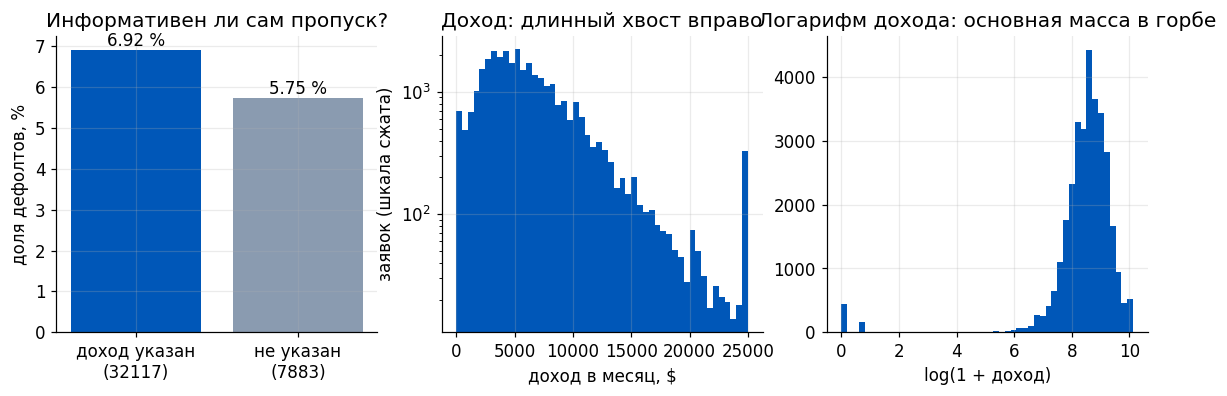

Что мы узнали про доход:
   доход указан:    заявок 32117, доля дефолтов 6.9 %
   доход не указан: заявок  7883, доля дефолтов 5.7 %
   из указанных доход равен нулю: 437
   медианный доход: 5366 $


In [50]:
## ── считаем ────────────────────────────────────────────────────────
no_income = credit["доход_в_месяц"].isna()
# dropna выбрасывает пропуски; log1p — это log(1 + x), он не боится нулей
income = credit["доход_в_месяц"].dropna().clip(upper=25000)

## ── графики ────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(12.8, 3.5))
ax[0].bar(["доход указан\n(%d)" % (~no_income).sum(), "не указан\n(%d)" % no_income.sum()],
          [100 * default[~no_income].mean(), 100 * default[no_income].mean()],
          color=[BLUE, GREY])
ax[0].set_ylabel("доля дефолтов, %")
ax[0].set_title("Информативен ли сам пропуск?")
for i, v in enumerate([100 * default[~no_income].mean(), 100 * default[no_income].mean()]):
    ax[0].text(i, v, "%.2f %%" % v, ha="center", va="bottom")
ax[1].hist(income, bins=50, color=BLUE)
ax[1].set_yscale("log")
ax[1].set_xlabel("доход в месяц, $")
ax[1].set_title("Доход: длинный хвост вправо")
ax[1].set_ylabel("заявок (шкала сжата)")
ax[2].hist(np.log1p(income), bins=50, color=BLUE)
ax[2].set_xlabel("log(1 + доход)")
ax[2].set_title("Логарифм дохода: основная масса в горбе")
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("Что мы узнали про доход:")
print("   доход указан:    заявок %5d, доля дефолтов %.1f %%"
      % ((~no_income).sum(), 100 * default[~no_income].mean()))
print("   доход не указан: заявок %5d, доля дефолтов %.1f %%"
      % (no_income.sum(), 100 * default[no_income].mean()))
print("   из указанных доход равен нулю: %d" % (income == 0).sum())
print("   медианный доход: %.0f $" % income.median())

Разница небольшая, но она есть, и знак неожиданный: у тех, кто не указал
доход, дефолтов **чуть меньше**. Значит, пропуск — не случайность, и его
стоит отметить отдельным столбцом, а не просто затереть медианой.

Сам доход скошен так же, как цены домов в первой части, — берём
логарифм. На третьей картинке видно, что он делает: основная масса
собралась в аккуратный горб вокруг типичных пяти тысяч, и теперь разница
между доходом 3 и 6 тысяч весит для модели столько же, сколько между
30 и 60 тысячами. Заодно видно и то, чего логарифм не лечит: слева
остался тонкий хвост — это 437 заявителей, указавших доход ноль.
Их немного, и мы их не трогаем, но знать про них стоит.

Добавляем три столбца: логарифм дохода, флаг «доход не указан» и число
иждивенцев.

Доход перед логарифмом обрезаем сверху на **25 000 $** — тем же порогом,
что и на картинке выше: заявок с доходом больше двадцати пяти тысяч
в месяц единицы, и тянуть за ними шкалу незачем. Логарифм берём через
`np.log1p`: это log(1 + x), он не спотыкается на нулевом доходе.

Шаг 4: ROC-AUC на валидации 0.8499 (на шаге 3 было 0.8501), столбцов в модели 12
Шаг «4. + доход и иждивенцы»: ROC-AUC на валидации = 0.8499
   на шаге «3. коды 96/98 → метка» было 0.8501 — стало хуже на 0.0003


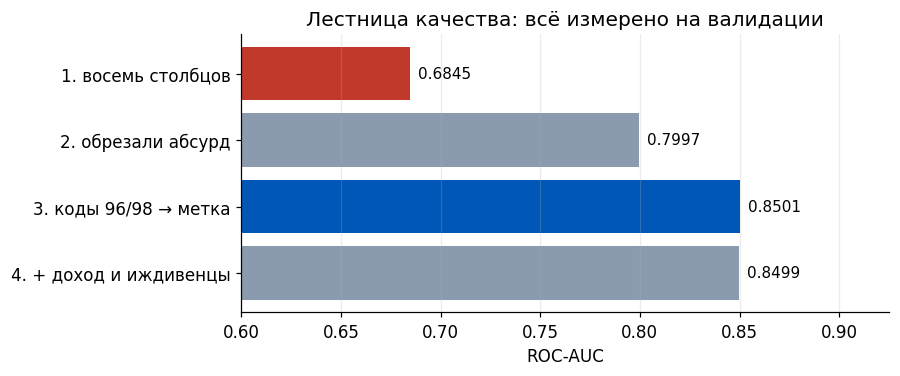

In [51]:
## ── новые столбцы ──────────────────────────────────────────────────
fixed["доход_неизвестен"] = credit["доход_в_месяц"].isna().astype(int)
fixed["log_доход"] = np.log1p(credit["доход_в_месяц"].clip(upper=25000))
fixed["иждивенцев"] = credit["иждивенцев"]

BASE4 = BASE3 + ["log_доход", "доход_неизвестен", "иждивенцев"]

## ── обучение ───────────────────────────────────────────────────────
c4 = Pipeline([
    ("пропуски", SimpleImputer(strategy="median")),
    ("масштаб", StandardScaler()),
    ("модель", LogisticRegression(max_iter=3000)),
])
c4.fit(fixed.loc[ctrain, BASE4], default.loc[ctrain])

## ── качество на валидации ──────────────────────────────────────────
p4 = c4.predict_proba(fixed.loc[cvalid, BASE4])[:, 1]
auc4 = roc_auc_score(default.loc[cvalid], p4)

print("Шаг 4: ROC-AUC на валидации %s (на шаге 3 было %s), столбцов в модели %d"
      % (show(auc4), show(auc3), len(BASE4)))
remember(CLADDER, "4. + доход и иждивенцы", auc4, "ROC-AUC", lower_better=False)
show_ladder(CLADDER, "Лестница качества: всё измерено на валидации",
            lower_better=False, start=0.6)

Качество практически не изменилось. Это нормальный результат шага:
доход в этих данных оказался слабым признаком, и три столбца ничего
не добавили.

Но работа не напрасна. Во-первых, теперь модель принимает заявки
с незаполненным доходом — а их пятая часть потока. Во-вторых, мы
узнали про сам пропуск то, чего не знали. Ценность шага не всегда
измеряется метрикой.

## Шаг 5. Граница применимости: риск нелинеен

Как и в первой части, упираемся в саму модель. Логистическая регрессия
складывает вклады и считает, что каждая следующая просрочка добавляет
к риску одинаково. Проверим.

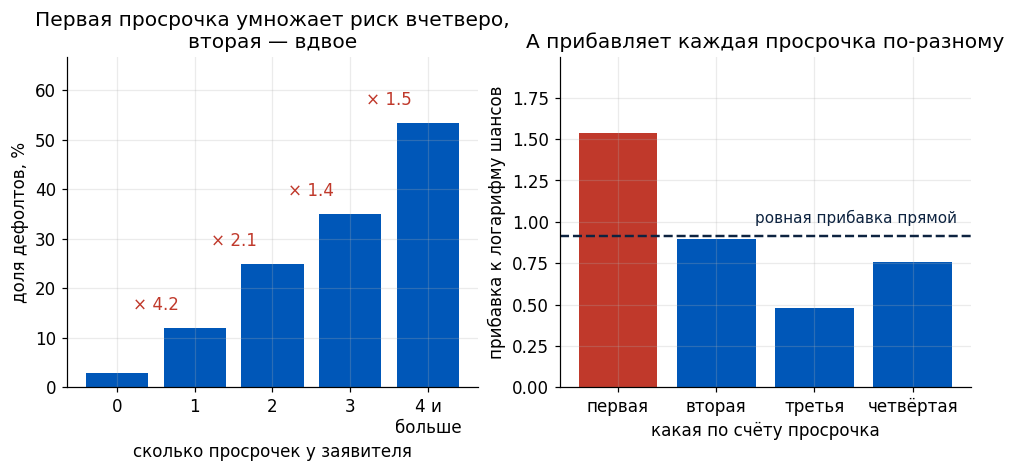

просрочек   доля дефолтов  логарифм шансов   заявок
0                    2.8 %          -3.5332    32099
1                   11.9 %          -1.9983     4498
2                   25.0 %          -1.1012     1575
3                   34.9 %          -0.6222      773
4                   53.4 %           0.1348     1055


In [52]:
## ── считаем риск и логарифм шансов ─────────────────────────────────
# сколько всего просрочек у заявителя; clip(upper=4) сводит «4 и больше» в одну группу
late = fixed[PAST_DUE].fillna(0).sum(axis=1).clip(upper=4)
# agg считает сразу несколько величин по каждой группе
by_late = default.groupby(late).agg(["mean", "size"])
risk = by_late["mean"].to_numpy()

# логарифм шансов: шансы = сколько дефолтов на одного вернувшего.
# Именно эту величину складывает логистическая регрессия из лекции,
# и по этой шкале она обязана шагать равномерно
logit = np.log(risk / (1 - risk))
steps = np.diff(logit)                  # прибавка от каждой следующей просрочки
even = steps.mean()                     # столько прибавляла бы прямая

## ── графики ────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(10.6, 3.9))

ax[0].bar(range(5), 100 * risk, color=BLUE)
for i in range(4):
    ax[0].annotate("× %.1f" % (risk[i + 1] / risk[i]), (i + 0.5, 100 * risk[i + 1]),
                   xytext=(0, 12), textcoords="offset points", ha="center",
                   color=RED, fontsize=11)
ax[0].set_xticks(range(5))
ax[0].set_xticklabels(["0", "1", "2", "3", "4 и\nбольше"])
ax[0].set_ylim(0, 100 * risk.max() * 1.25)
ax[0].set_xlabel("сколько просрочек у заявителя")
ax[0].set_ylabel("доля дефолтов, %")
ax[0].set_title("Первая просрочка умножает риск вчетверо,\nвторая — вдвое")

ax[1].bar(range(1, 5), steps, color=[RED] + [BLUE] * 3)
ax[1].axhline(even, color=INK, lw=1.6, ls="--")
ax[1].set_ylim(0, steps.max() * 1.3)
ax[1].annotate("ровная прибавка прямой", (4.45, even), xytext=(0, 8),
               textcoords="offset points", ha="right", fontsize=10, color=INK)
ax[1].set_xticks(range(1, 5))
ax[1].set_xticklabels(["первая", "вторая", "третья", "четвёртая"])
ax[1].set_xlabel("какая по счёту просрочка")
ax[1].set_ylabel("прибавка к логарифму шансов")
ax[1].set_title("А прибавляет каждая просрочка по-разному")
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("%-10s %14s %16s %8s"
      % ("просрочек", "доля дефолтов", "логарифм шансов", "заявок"))
for n, r, l, s in zip(by_late.index, risk, logit, by_late["size"]):
    print("%-10d %13.1f %% %16s %8d" % (n, 100 * r, show(l), s))

Слева — резкий скачок: у заёмщика без просрочек риск 2,8 %, с одной
просрочкой — 11,9 %, вчетверо больше. Вторая просрочка добавляет уже
только вдвое, третья — в 1,4 раза.

Справа то же самое в той шкале, в которой работает модель. Первая
просрочка прибавляет к логарифму шансов 1,5, а третья — 0,5. Прямая так
не умеет: она обязана прибавлять одинаково, около 0,9 за каждую
просрочку (пунктир). Значит, первую просрочку она недооценит, а четвёртую
переоценит.

Выходит, в самом числе просрочек не хватает одного факта: **была ли
просрочка вообще**. Его и добавим отдельным столбцом.

Шаг 5:
   ROC-AUC на валидации: 0.8532
   было на шаге 4:       0.8499
   столбцов в модели:    13
Шаг «5. + флаг просрочки»: ROC-AUC на валидации = 0.8532
   на шаге «4. + доход и иждивенцы» было 0.8499 — стало лучше на 0.0033


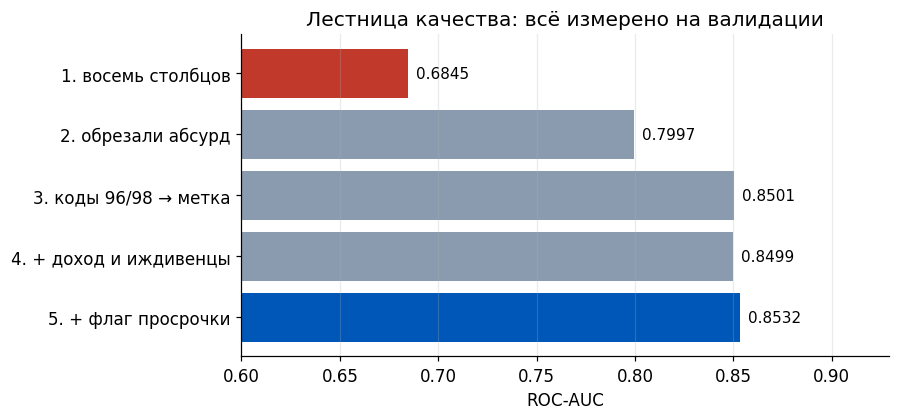

In [53]:
## ── новый столбец: был ли факт просрочки ───────────────────────────
fixed["была_просрочка"] = (fixed[PAST_DUE].fillna(0).sum(axis=1) > 0).astype(int)
# этот набор столбцов и есть итоговый для второй части
FINAL = BASE4 + ["была_просрочка"]

## ── обучение ───────────────────────────────────────────────────────
c5 = Pipeline([("пропуски", SimpleImputer(strategy="median")),
               ("масштаб", StandardScaler()),
               ("модель", LogisticRegression(max_iter=3000))])
c5.fit(fixed.loc[ctrain, FINAL], default.loc[ctrain])

## ── качество на валидации ──────────────────────────────────────────
p5 = c5.predict_proba(fixed.loc[cvalid, FINAL])[:, 1]
auc5 = roc_auc_score(default.loc[cvalid], p5)

print("Шаг 5:")
print("   ROC-AUC на валидации: %s" % show(auc5))
print("   было на шаге 4:       %s" % show(auc4))
print("   столбцов в модели:    %d" % len(FINAL))
remember(CLADDER, "5. + флаг просрочки", auc5, "ROC-AUC", lower_better=False)
show_ladder(CLADDER, "Лестница качества: всё измерено на валидации",
            lower_better=False, start=0.6)

Флаг помог: модель получила тот самый факт, которого ей не хватало, —
была ли просрочка вообще. Само число просрочек мы при этом оставили,
вместе эти два столбца и дают ту ломаную, которую одна прямая
изобразить не может.

На этом с признаками всё: тринадцать столбцов и ROC-AUC 0,85 против
0,68 на первом шаге. Осталось главное — превратить оценку риска
в решение «выдавать или нет».

## Шаг 6. Порог: считаем деньгами

Модель выдаёт число от 0 до 1, а банку нужно решение: выдавать или нет.
Превращает одно в другое **порог**: выдаём, если оценка риска ниже него.
Прибыль портфеля при пороге $t$ считается прямо по экономике из начала
части:

$$\text{прибыль}(t) \;=\; 0{,}03 \cdot \sum_{i \,\in\, \text{выдали и вернул}} S_i
\;-\; 0{,}5 \cdot \sum_{i \,\in\, \text{выдали и дефолт}} S_i$$

Читается так: берём заявки, которым модель дала оценку риска ниже порога
(им кредит выдан); с каждой вернувшейся банк зарабатывает 3 % суммы,
на каждой ушедшей в дефолт теряет 50 %. Сумма кредита $S_i$ — три
месячных дохода заявителя. Отказы в формулу не входят: они не приносят
ни прибыли, ни убытка.

**Всё в этом шаге считается на валидации.** Порог — такой же выбор, как
выбор признаков, и делать его по тесту нельзя. Тест откроем на шаге 7.

In [54]:
## ── экономика и модель ─────────────────────────────────────────────
GAIN, LOSS = 0.03, 0.5      # зарабатываем 3 % с вернувшегося, теряем 50 % на дефолте

# в работу идёт модель шага 5 — та же, ничего заново не обучаем
final_model = c5
p_valid = final_model.predict_proba(fixed.loc[cvalid, FINAL])[:, 1]

## ── сумма кредита ──────────────────────────────────────────────────
# сумма кредита — три месячных дохода; где доход не указан, берём медианный
# (fillna заполняет пропуски заданным значением)
amount = 3 * credit["доход_в_месяц"].fillna(credit["доход_в_месяц"].median())


## ── функция: прибыль портфеля ──────────────────────────────────────
def profit(p, thr, rows):
    "Прибыль портфеля на заданных заявках: выдаём кредит, если оценка риска ниже порога."
    give = p < thr
    money = amount.loc[rows].to_numpy()
    real = default.loc[rows].to_numpy()
    return GAIN * money[give & (real == 0)].sum() - LOSS * money[give & (real == 1)].sum()


## ── числа ──────────────────────────────────────────────────────────
print("Шаг 6, всё на валидации:")
print("   средняя сумма кредита:                 %s"
      % show(amount.loc[cvalid].mean(), "$"))
print("   заявок, где модель даёт риск выше 0,5: %.2f %%"
      % (100 * (p_valid > 0.5).mean()))
print("   прибыль, если выдать всем:             %s"
      % show(profit(p_valid, 1.0, cvalid), "$"))
print("   прибыль при пороге 0,5:                %s"
      % show(profit(p_valid, 0.5, cvalid), "$"))

Шаг 6, всё на валидации:
   средняя сумма кредита:                 19067.33 $
   заявок, где модель даёт риск выше 0,5: 1.89 %
   прибыль, если выдать всем:             -334390.20 $
   прибыль при пороге 0,5:                284079.36 $


Смотрите на вторую строку: оценку выше 0,5 модель даёт меньше чем двум
процентам заявителей. То есть **привычный порог 0,5 почти никого
не отсекает** — при дисбалансе 1 к 14 модель почти никогда не бывает
уверена в дефолте. И всё-таки даже он выводит портфель из убытка в плюс.
Значит, порог — это рычаг, и его надо настроить.

Считаем прибыль при всех порогах подряд, находим самый выгодный
и сравниваем три стратегии: выдать всем, порог 0,5 и найденный порог.

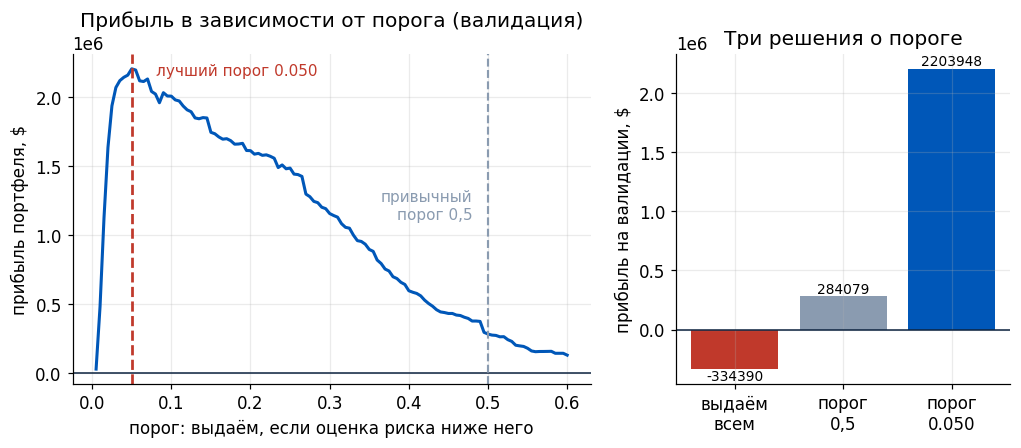

стратегия          прибыль на валидации   одобрено заявок
выдаём всем                -334390.20 $            100.0 %
порог 0,5                   284079.36 $             98.1 %
порог 0.050                2203947.81 $             71.0 %

теоретический порог выигрыш / (выигрыш + потеря) = 0.0566


In [55]:
## ── перебираем пороги ──────────────────────────────────────────────
grid = np.linspace(0.005, 0.6, 120)        # linspace: 120 порогов от 0,005 до 0,6
money_curve = np.array([profit(p_valid, t, cvalid) for t in grid])

# argmax находит номер самого большого элемента — это и есть лучший порог
best_t = grid[int(np.argmax(money_curve))]
theory = GAIN / (GAIN + LOSS)

## ── графики ────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.9),
                       gridspec_kw={"width_ratios": [1.55, 1]})
ax[0].plot(grid, money_curve, color=BLUE, lw=2)
ax[0].axhline(0, color=INK, lw=1)
ax[0].axvline(best_t, color=RED, lw=1.8, ls="--")
ax[0].annotate("лучший порог %.3f" % best_t, (best_t, money_curve.max()),
               xytext=(16, -4), textcoords="offset points", color=RED, fontsize=10)
ax[0].axvline(0.5, color=GREY, ls="--", lw=1.4)
ax[0].annotate("привычный\nпорог 0,5", (0.5, money_curve.max() * 0.55),
               xytext=(-10, 0), textcoords="offset points", ha="right",
               va="center", color=GREY, fontsize=10)
ax[0].set_xlabel("порог: выдаём, если оценка риска ниже него")
ax[0].set_ylabel("прибыль портфеля, $")
ax[0].set_title("Прибыль в зависимости от порога (валидация)")

vals = [profit(p_valid, 1.0, cvalid), profit(p_valid, 0.5, cvalid),
        profit(p_valid, best_t, cvalid)]
ax[1].bar(["выдаём\nвсем", "порог\n0,5", "порог\n%.3f" % best_t], vals,
          color=[RED, GREY, BLUE])
ax[1].axhline(0, color=INK, lw=1)
for i, v in enumerate(vals):
    ax[1].text(i, v, "%.0f" % v, ha="center", va="bottom" if v > 0 else "top",
               fontsize=9)
ax[1].set_ylabel("прибыль на валидации, $")
ax[1].set_title("Три решения о пороге")
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("%-16s %22s %17s"
      % ("стратегия", "прибыль на валидации", "одобрено заявок"))
for name, thr in (("выдаём всем", 1.0), ("порог 0,5", 0.5),
                  ("порог %.3f" % best_t, best_t)):
    print("%-16s %22s %16.1f %%"
          % (name, show(profit(p_valid, thr, cvalid), "$"),
             100 * (p_valid < thr).mean()))
print("\nтеоретический порог выигрыш / (выигрыш + потеря) = %s" % show(theory))

Выдавать всем — **убыток**: 6,7 % дефолтов съедают прибыль с остальных.
Порог 0,5 выводит портфель в плюс, но правильный порог даёт в несколько
раз больше.

И снова его можно было посчитать на бумаге:

$$t^* = \frac{\text{выигрыш}}{\text{выигрыш} + \text{потеря}}
= \frac{0{,}03}{0{,}03 + 0{,}5} = 0{,}057$$

Выдавать кредит стоит там, где ожидаемая прибыль больше ожидаемых
потерь: $(1-p) \cdot 0{,}03 > p \cdot 0{,}5$. Перебор нашёл почти это же
число — значит, модель выдаёт осмысленные вероятности.

## Шаг 7. Открываем тест

In [56]:
## ── прогноз на тесте ───────────────────────────────────────────────
p_test = final_model.predict_proba(fixed.loc[ctest, FINAL])[:, 1]

## ── числа ──────────────────────────────────────────────────────────
print("Качество на %d заявках, которых никто не видел:" % len(ctest))
print("   ROC-AUC на тесте:         %s"
      % show(roc_auc_score(default.loc[ctest], p_test)))
print("   ROC-AUC на валидации был: %s" % show(auc5))

print("\nПрибыль портфеля на тесте:")
for name, t in (("выдаём всем", 1.0), ("порог 0,5", 0.5),
                ("порог %.3f" % best_t, best_t)):
    print("   %-14s %16s   одобрено %.1f %%"
          % (name, show(profit(p_test, t, ctest), "$"), 100 * (p_test < t).mean()))

Качество на 8000 заявках, которых никто не видел:
   ROC-AUC на тесте:         0.8480
   ROC-AUC на валидации был: 0.8532

Прибыль портфеля на тесте:
   выдаём всем         -56901.39 $   одобрено 100.0 %
   порог 0,5           527170.65 $   одобрено 98.0 %
   порог 0.050        2131874.58 $   одобрено 72.0 %


Порог мы выбрали на валидации и только потом применили к тесту.
Проверим, насколько он подошёл: нарисуем ту же кривую прибыли, но на
тесте, и отметим на ней наш порог.

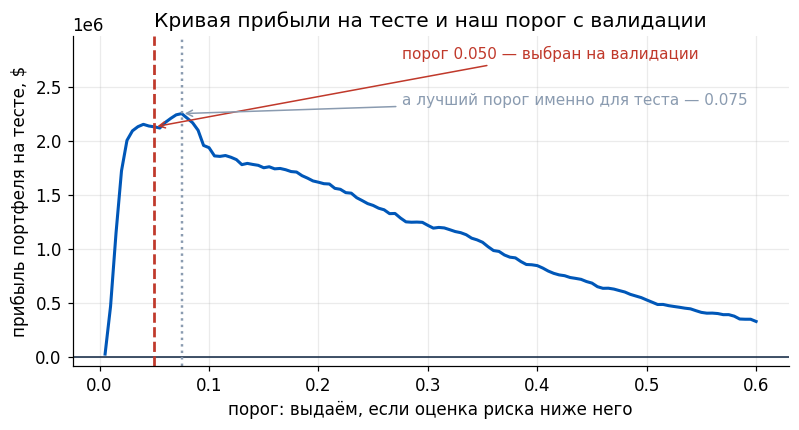

Насколько подошёл порог с валидации:
   прибыль при нашем пороге 0.050:            2131874.58 $
   прибыль при лучшем пороге для теста 0.075: 2254564.95 $
   разница — цена того, что мы не подсматривали в тест: 122690.37 $ (5.4 %)


In [57]:
## ── кривая прибыли на тесте ────────────────────────────────────────
curve_test = np.array([profit(p_test, t, ctest) for t in grid])
t_best_test = grid[int(np.argmax(curve_test))]
money_ours = profit(p_test, best_t, ctest)

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8.4, 3.9))
ax.plot(grid, curve_test, color=BLUE, lw=2)
ax.axhline(0, color=INK, lw=1)
ax.set_ylim(top=curve_test.max() * 1.32)
ax.axvline(best_t, color=RED, lw=1.8, ls="--")
ax.annotate("порог %.3f — выбран на валидации" % best_t, (best_t, money_ours),
            xytext=(0.46, 0.93), textcoords="axes fraction", color=RED, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=RED))
ax.axvline(t_best_test, color=GREY, lw=1.6, ls=":")
ax.annotate("а лучший порог именно для теста — %.3f" % t_best_test,
            (t_best_test, curve_test.max()), xytext=(0.46, 0.79),
            textcoords="axes fraction", color=GREY, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=GREY))
ax.set_xlabel("порог: выдаём, если оценка риска ниже него")
ax.set_ylabel("прибыль портфеля на тесте, $")
ax.set_title("Кривая прибыли на тесте и наш порог с валидации")
plt.show()

## ── числа ──────────────────────────────────────────────────────────
print("Насколько подошёл порог с валидации:")
print("   прибыль при нашем пороге %.3f:            %s"
      % (best_t, show(money_ours, "$")))
print("   прибыль при лучшем пороге для теста %.3f: %s"
      % (t_best_test, show(curve_test.max(), "$")))
print("   разница — цена того, что мы не подсматривали в тест: %s (%.1f %%)"
      % (show(curve_test.max() - money_ours, "$"),
         100 * (1 - money_ours / curve_test.max())))

Кривая прибыли пологая у вершины, поэтому порог, выбранный на валидации,
потерял всего несколько процентов от идеального. Это и есть нормальная
работа: мы не знаем будущего и выбираем порог заранее — а плата
за незнание оказалась небольшой.

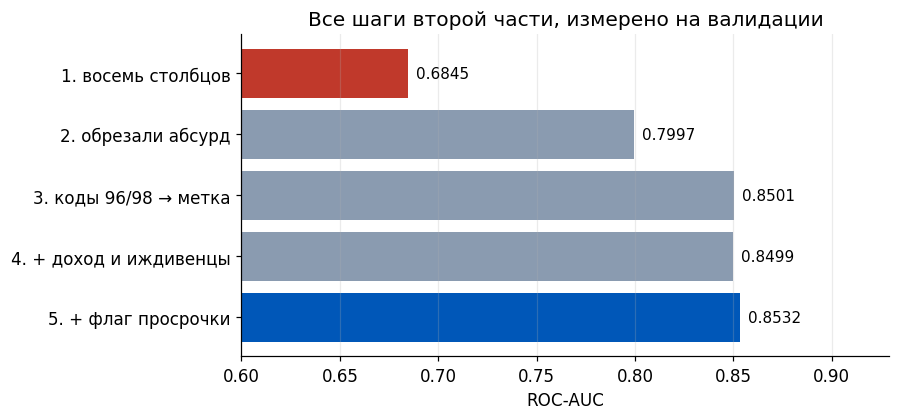

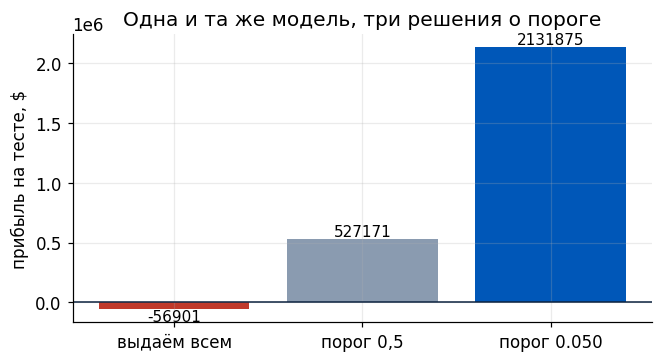

In [58]:
## ── лестница ───────────────────────────────────────────────────────
show_ladder(CLADDER, "Все шаги второй части, измерено на валидации",
            lower_better=False, start=0.6)

## ── считаем ────────────────────────────────────────────────────────
names = ["выдаём всем", "порог 0,5", "порог %.3f" % best_t]
vals = [profit(p_test, 1.0, ctest), profit(p_test, 0.5, ctest), money_ours]

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.8, 3.4))
ax.bar(names, vals, color=[RED, GREY, BLUE])
ax.axhline(0, color=INK, lw=1)
ax.set_ylabel("прибыль на тесте, $")
ax.set_title("Одна и та же модель, три решения о пороге")
for i, v in enumerate(vals):
    ax.text(i, v, "%.0f" % v, ha="center", va="bottom" if v > 0 else "top", fontsize=10)
plt.show()

## Шаг 8. Сколько стоит один пункт AUC

Шаг за шагом мы двигали AUC: 0,68 → 0,85. Бизнес-заказчик задаст
ровно один вопрос: **а в деньгах это сколько?** Переведём.

Возьмём модели с четырёх шагов. Для каждой подберём **её собственный**
лучший порог на валидации — у моделей разное качество, значит и пороги
разные, — а прибыль посчитаем на тесте.

модель                                     AUC тест    порог   прибыль на тесте
шаг 1: восемь столбцов как есть              0.6955   0.0700       1326600.48 $
шаг 3: абсурд обрезан, коды разобраны        0.8391   0.0550       2085625.17 $
шаг 4: + доход и иждивенцы                   0.8384   0.0650       1986809.73 $
шаг 5: финальная модель                      0.8480   0.0500       2131874.58 $


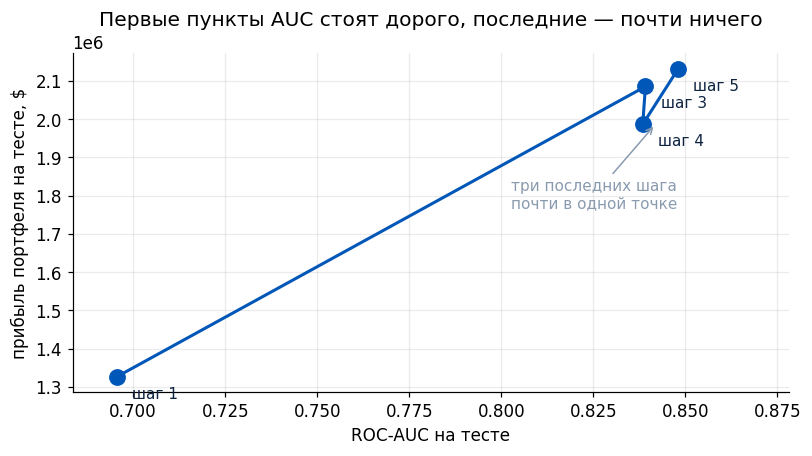

In [59]:
## ── четыре модели подряд ───────────────────────────────────────────
STAGES = [("шаг 1: восемь столбцов как есть", c1, credit, BASE),
          ("шаг 3: абсурд обрезан, коды разобраны", c3, fixed, BASE3),
          ("шаг 4: + доход и иждивенцы", c4, fixed, BASE4),
          ("шаг 5: финальная модель", final_model, fixed, FINAL)]

rows = []
for name, model, frame, cols in STAGES:
    pv = model.predict_proba(frame.loc[cvalid, cols])[:, 1]          # валидация: порог
    t = grid[int(np.argmax([profit(pv, thr, cvalid) for thr in grid]))]
    pt = model.predict_proba(frame.loc[ctest, cols])[:, 1]           # тест: качество и деньги
    rows.append((name, roc_auc_score(default.loc[ctest], pt), t, profit(pt, t, ctest)))

aucs = [r[1] for r in rows]
moneys = [r[3] for r in rows]

## ── числа ──────────────────────────────────────────────────────────
print("%-40s %10s %8s %18s"
      % ("модель", "AUC тест", "порог", "прибыль на тесте"))
for name, auc, t, money in rows:
    print("%-40s %10s %8s %18s" % (name, show(auc), show(t), show(money, "$")))

## ── график ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8.4, 4.0))
ax.plot(aucs, moneys, "o-", color=BLUE, lw=2, ms=10)
for name, auc, t, money in rows:
    ax.annotate(name.split(":")[0], (auc, money), xytext=(10, -14),
                textcoords="offset points", fontsize=10, color=INK)
ax.annotate("три последних шага\nпочти в одной точке",
            (np.mean(aucs[1:]), min(moneys[1:])), xytext=(-40, -55),
            textcoords="offset points", ha="center", fontsize=10, color=GREY,
            arrowprops=dict(arrowstyle="->", color=GREY))
ax.set_xlim(min(aucs) - 0.012, max(aucs) + 0.03)
ax.set_xlabel("ROC-AUC на тесте")
ax.set_ylabel("прибыль портфеля на тесте, $")
ax.set_title("Первые пункты AUC стоят дорого, последние — почти ничего")
plt.show()

In [60]:
## ── сколько денег стоит один пункт AUC ─────────────────────────────
# прибавку прибыли делим на прирост AUC и умножаем на 0,01 — один пункт
step = (moneys[1] - moneys[0]) / (aucs[1] - aucs[0]) * 0.01

print("Качество в деньгах, портфель из %d заявок:" % len(ctest))
print("   AUC вырос с %s до %s и принёс: %s"
      % (show(aucs[0]), show(aucs[1]), show(moneys[1] - moneys[0], "$")))
print("   то есть один пункт AUC стоит примерно: %s" % show(step, "$"))
print("   а шаги 3 → 5 (AUC с %s до %s) дали:    %s"
      % (show(aucs[1]), show(aucs[-1]), show(moneys[-1] - moneys[1], "$")))
print("   для сравнения: цена неточного порога с шага 7: %s"
      % show(curve_test.max() - money_ours, "$"))

Качество в деньгах, портфель из 8000 заявок:
   AUC вырос с 0.6955 до 0.8391 и принёс: 759024.69 $
   то есть один пункт AUC стоит примерно: 52852.73 $
   а шаги 3 → 5 (AUC с 0.8391 до 0.8480) дали:    46249.41 $
   для сравнения: цена неточного порога с шага 7: 122690.37 $


Линия сначала резко идёт вверх, а потом упирается в стенку — и это
главный вывод шага. Первое большое улучшение — разбор данных —
подняло AUC на 14 пунктов и принесло три четверти миллиона долларов
на восьми тысячах заявок: примерно 50 тысяч за каждый пункт AUC.

А три последних шага стоят почти в одной точке. Они отличаются друг
от друга меньше чем на пункт AUC, и разница в деньгах между ними того же
порядка, что и потеря от неточного порога с прошлого шага. То есть
на этом участке AUC уже не отличает хорошее решение от случайного.

Практический вывод: за AUC стоит гоняться, пока он растёт крупно — там
каждый пункт это реальные деньги. Когда рост измеряется тысячными,
прибыль приносит уже не модель, а правильный порог и точные цифры
выигрыша и потери, которые даёт риск-менеджмент.

## Итог второй части

AUC вырос с 0,68 до 0,85, и **весь рост дала работа с данными**:
обрезка абсурдных значений и разбор служебных кодов. Ни нового
алгоритма, ни настройки гиперпараметров для этого не потребовалось.

А деньги принёс порог. Это два разных разговора: с данными —
про то, что в них лежит, и с бизнесом — про то, сколько стоит ошибка.

---
# Итоги

Оба кейса прошли один и тот же цикл. Вот что в нём встретилось —
и заметьте, что проблемы делятся на два сорта.

**Проблемы данных** — они одинаковы для любой модели:

| Что нашли | Как узнали | Что сделали |
|---|---|---|
| текст вместо чисел | модель не обучилась | one-hot для категорий |
| пропуски | `isna().sum()` | медиана плюс флаг «не указано» |
| абсурдные значения | картинка разброса: доля больше 13 000 | обрезали хвост через `clip` |
| служебные коды 96 и 98 | `value_counts()`: скачок после 15 | значение в пропуск, факт — в отдельный столбец |
| выбросы | точки на диаграмме | нашли причину в другом столбце, убрали из обучения |
| столбцы дублируют друг друга | площади этажей в сумме дают жилую | дубли не взяли, иначе веса прыгают в разы |
| перекос распределения | остатки расширяются с ценой, длинный хвост на гистограмме | логарифм ответа и логарифм дохода |
| дисбаланс классов | accuracy пустышки 93 % | перешли на AUC и на деньги |

**Проблемы самой линейной модели** — от них не спасёт никакая чистка данных:

| Ограничение | Как проявилось | Чем лечили |
|---|---|---|
| складывает вклады, не перемножает | метр в доме с хорошей отделкой дороже в 1,7 раза | произведения признаков |
| один наклон на весь диапазон | первая просрочка поднимает риск вчетверо, вторая — вдвое | флаг «была просрочка» |
| чем больше столбцов, тем сильнее переобучение | обучение 13 тыс., валидация 16 тыс. | Ridge, `alpha` по кросс-валидации |
| выдаёт число, а не решение | порог 0,5 отсекал 2 % заявок | порог из цены ошибок |

**И пять правил, которые дороже любой из строк выше:**

1. Сначала посмотрите на данные глазами — разброс, `value_counts`,
   гистограмма. Обе самые большие прибавки за семинар пришли оттуда.
2. Гиперпараметры подбирают на обучающей части кросс-валидацией, а тест
   открывают один раз.
3. Одному разбиению верить нельзя: в первой части оно показало выигрыш,
   которого на тесте не оказалось. Кросс-валидация даёт разброс — и
   прирост меньше разброса улучшением не считается.
4. Шаги без прироста — нормальная часть работы. В каждом кейсе такой
   попался, и узнать это заранее было нельзя.
5. Прирост метрики стоит переводить в деньги. В скоринге первые пункты
   AUC принесли по 50 тысяч долларов каждый, а последние оказались
   дешевле, чем правильно выбранный порог.

**Что дальше.** Обе модели упирались в одно: они складывают вклады
признаков, и всё нелинейное приходится придумывать руками. На следующей
лекции появятся деревья решений — они находят такие взаимодействия сами.